# ✈️ NASA C-MAPSS FD003 — EDA + 전처리 + Feature Engineering + Validation Split 파이프라인

**[FD003 최적화]** 상수 센서 제거(Fan 센서 재검토) → **고장 모드 클러스터링(KMeans k=2)** → RUL cap → Gaussian → Validation 분리 → 전체 정규화

공통: 상수 센서 제거 → **고장 모드 클러스터링** → RUL cap=125 → Gaussian(σ=2) → Validation 분리(엔진 단위 random) → 전체 MinMax  
ML 분기: lag·diff·rolling·std·EMA + fault_mode_cluster 피처  |  DL 분기: 슬라이딩 윈도우(window=30)

> **FD003 vs FD001 핵심 차이**  
> - 운전 조건: **1가지 (Sea Level) — FD001과 동일**  
> - 훈련 엔진: 100대 — FD001과 동일  
> - 고장 모드: 1개(HPC) → **2개(HPC + Fan 열화)**  
> - 정규화 전략: **전체 MinMax (운전조건 1개이므로 FD001과 동일)**  
> - **신규**: 고장 모드 클러스터링(KMeans k=2) → fault_mode_cluster 피처 추가  
> - Fan 관련 센서(s_1, s_5, s_6 등) 상수 여부 재검토

## 0. 환경 설정

In [46]:
import sys, subprocess
for pkg in ['numpy','pandas','scikit-learn','scipy','matplotlib','seaborn']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])
print('✅ 라이브러리 설치 완료')

✅ 라이브러리 설치 완료


In [47]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import platform
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ks_2samp, kendalltau
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# ── 한글 폰트 ─────────────────────────────────────────────────────────────
import logging
import matplotlib.font_manager as fm
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

def force_korean_font():
    system = platform.system()
    if system == "Windows":
        font_path = "C:/Windows/Fonts/malgun.ttf"
        font_name = "Malgun Gothic"
    elif system == "Darwin":
        font_path = "/System/Library/Fonts/AppleGothic.ttf"
        font_name = "AppleGothic"
    else:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        font_name = "NanumGothic"
        if not os.path.exists(font_path):
            os.system("apt-get update -qq")
            os.system("apt-get install -y fonts-nanum -qq")
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = font_name
        plt.rcParams["font.sans-serif"] = [font_name]
        plt.rcParams["axes.unicode_minus"] = False
        print(f"✅ 한글 폰트 적용: {font_name}")
    else:
        print("❌ 폰트 못 찾음")

force_korean_font()

# ── 다크 테마 ─────────────────────────────────────────────────────────────
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
FAULT_COLORS  = ['#00d4ff', '#ff6b6b']   # 고장모드 0=파랑, 1=빨강

plt.rcParams.update({
    'figure.facecolor':BG,  'axes.facecolor':BG2,
    'axes.edgecolor':GRID,  'axes.labelcolor':GRAY,
    'xtick.color':GRAY,     'ytick.color':GRAY,
    'text.color':WHITE,     'grid.color':GRID,
    'grid.alpha':0.4,       'axes.grid':True,
    'font.size':10,         'axes.titlesize':11,
    'legend.facecolor':BG2, 'legend.edgecolor':GRID,
})
force_korean_font()

# ── 전역 상수 ─────────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1','op2':'setting_2','op3':'setting_3',
    **{f's{i}':f's_{i}' for i in range(1,22)}
}

SENSOR_COLS  = [f's_{i}' for i in range(1,22)]
OP_COLS      = ['setting_1','setting_2','setting_3']
ID_COLS      = ['unit_nr','time_cycles']
RUL_CAP      = 125
GAUSS_SIGMA  = 2
CONST_THR    = 0.01

# FD003 전용 상수
N_FAULT_MODES = 2     # HPC 열화 + Fan 열화
SLOPE_WINDOW  = 30    # 고장모드 클러스터링용 마지막 N 사이클

# FD003 — Fan / HPC 관련 센서 (클러스터 해석에 사용)
FAN_SENSORS = ['s_1','s_6','s_8','s_13','s_15']
HPC_SENSORS = ['s_3','s_7','s_9','s_11','s_12']

TEMPORAL_LAGS      = [1, 3, 5]
TEMPORAL_DIFFS     = [1]
TEMPORAL_ROLLS     = [3, 5]
TEMPORAL_ROLL_STDS = [3, 5]
TEMPORAL_EMAS      = [5]

WINDOW_SIZE = 30
STEP        = 1

SENSOR_DESC = {
    's_1':'T2 팬 입구 온도(°R)',       's_2':'T24 LPC 출구 온도(°R)',
    's_3':'T30 HPC 출구 온도(°R)',     's_4':'T50 LPT 출구 온도(°R)',
    's_5':'P2 팬 입구 압력(psia)',      's_6':'P15 바이패스 압력(psia)',
    's_7':'P30 HPC 출구 압력(psia)',   's_8':'Nf 팬 속도(rpm)',
    's_9':'Nc 코어 속도(rpm)',          's_10':'epr 엔진 압력비',
    's_11':'Ps30 정적압력(psia)',       's_12':'phi 연료/Ps30 비율',
    's_13':'NRf 보정 팬 속도(rpm)',     's_14':'NRc 보정 코어속도(rpm)',
    's_15':'BPR 바이패스 비율',         's_16':'farB 버너 연료공기비',
    's_17':'htBleed 블리드 엔탈피',     's_18':'Nf_dmd 요구 팬 속도',
    's_19':'PCNfR 요구 보정 팬속도',    's_20':'W31 HPT 냉각블리드',
    's_21':'W32 LPT 냉각블리드',
}

print('✅ 환경 설정 완료')
print(f'   RUL Cap={RUL_CAP}  |  σ={GAUSS_SIGMA}  |  상수 기준 std<{CONST_THR}')
print(f'   고장 모드 수={N_FAULT_MODES}  |  Slope window={SLOPE_WINDOW}  |  Window={WINDOW_SIZE}')

✅ 한글 폰트 적용: Malgun Gothic
✅ 한글 폰트 적용: Malgun Gothic
✅ 환경 설정 완료
   RUL Cap=125  |  σ=2  |  상수 기준 std<0.01
   고장 모드 수=2  |  Slope window=30  |  Window=30


## 1. 데이터 로딩 & 컬럼명 표준화

In [48]:
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData','./CMAPSSData','../CMAPSSData']:
    if os.path.exists(os.path.join(c,'train_FD003.txt')):
        DATA_DIR = c; break
else:
    print(f'❌ 경로 없음. 현재: {os.getcwd()}')

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD003.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD003.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD003.txt', sep=r'\s+', header=None, names=['RUL'], engine='python')

train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename( columns=RENAME_MAP, inplace=True)

print('✅ FD003 로딩 완료')
print(f'   Train : {train_raw.shape}  |  엔진 {train_raw["unit_nr"].nunique()}대')
print(f'   Test  : {test_raw.shape}   |  엔진 {test_raw["unit_nr"].nunique()}대')
print(f'   RUL   : {rul_df.shape}')
print(f'\n표준화 컬럼: {list(train_raw.columns)}')
display(train_raw.head(3))

✅ FD003 로딩 완료
   Train : (24720, 26)  |  엔진 100대
   Test  : (16596, 26)   |  엔진 100대
   RUL   : (100, 1)

표준화 컬럼: ['unit_nr', 'time_cycles', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19', 's_20', 's_21']


,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669


---
## 2. 전처리 전 EDA
### 2-1. 기초 통계 & 데이터 품질

In [49]:
print('=== 기초 통계 & 데이터 품질 검사 ===')

quality = pd.DataFrame({
    '구분'       : ['Train','Test'],
    '전체 행'    : [len(train_raw), len(test_raw)],
    '결측치'     : [train_raw.isnull().sum().sum(), test_raw.isnull().sum().sum()],
    '중복 행'    : [train_raw.duplicated().sum(), test_raw.duplicated().sum()],
    '음수 센서'  : [(train_raw[SENSOR_COLS]<0).sum().sum(), (test_raw[SENSOR_COLS]<0).sum().sum()],
    '엔진 수'    : [train_raw['unit_nr'].nunique(), test_raw['unit_nr'].nunique()],
    '판정'       : ['✅ 정상','✅ 정상'],
}).set_index('구분')
display(quality)

print('\n--- 센서별 기술통계 (Train) ---')
desc = train_raw[SENSOR_COLS].describe().T
desc['CV(변동계수)'] = (desc['std'] / desc['mean'].abs()).round(5)
display(desc[['mean','std','min','max','CV(변동계수)']].style
        .background_gradient(subset=['CV(변동계수)'], cmap='YlOrRd').format('{:.4f}'))
print('\n📌 CV ≈ 0 → 열화 정보 없음 → 제거 대상')
print('📌 FD003 주목: Fan 관련 센서(s_1, s_6, s_8, s_13, s_15)의 CV 확인 (FD001 대비 변동 증가 예상)')

=== 기초 통계 & 데이터 품질 검사 ===


,전체 행,결측치,중복 행,음수 센서,엔진 수,판정
구분,,,,,,
Train,24720,0,0,0,100,✅ 정상
Test,16596,0,0,0,100,✅ 정상



--- 센서별 기술통계 (Train) ---


,mean,std,min,max,CV(변동계수)
s_1,518.6700,0.0000,518.6700,518.6700,0.0000
s_2,642.4579,0.5230,640.8400,645.1100,0.0008
s_3,1588.0792,6.8104,1564.3000,1615.3900,0.0043
s_4,1404.4712,9.7732,1377.0600,1441.1600,0.0070
s_5,14.6200,0.0000,14.6200,14.6200,0.0000
s_6,21.5958,0.0181,21.4500,21.6100,0.0008
s_7,555.1438,3.4373,549.6100,570.4900,0.0062
s_8,2388.0716,0.1583,2386.9000,2388.6000,0.0001
s_9,9064.1108,19.9803,9017.9800,9234.3500,0.0022
s_10,1.3012,0.0035,1.2900,1.3200,0.0027



📌 CV ≈ 0 → 열화 정보 없음 → 제거 대상
📌 FD003 주목: Fan 관련 센서(s_1, s_6, s_8, s_13, s_15)의 CV 확인 (FD001 대비 변동 증가 예상)


### 2-2. 엔진 수명 분포

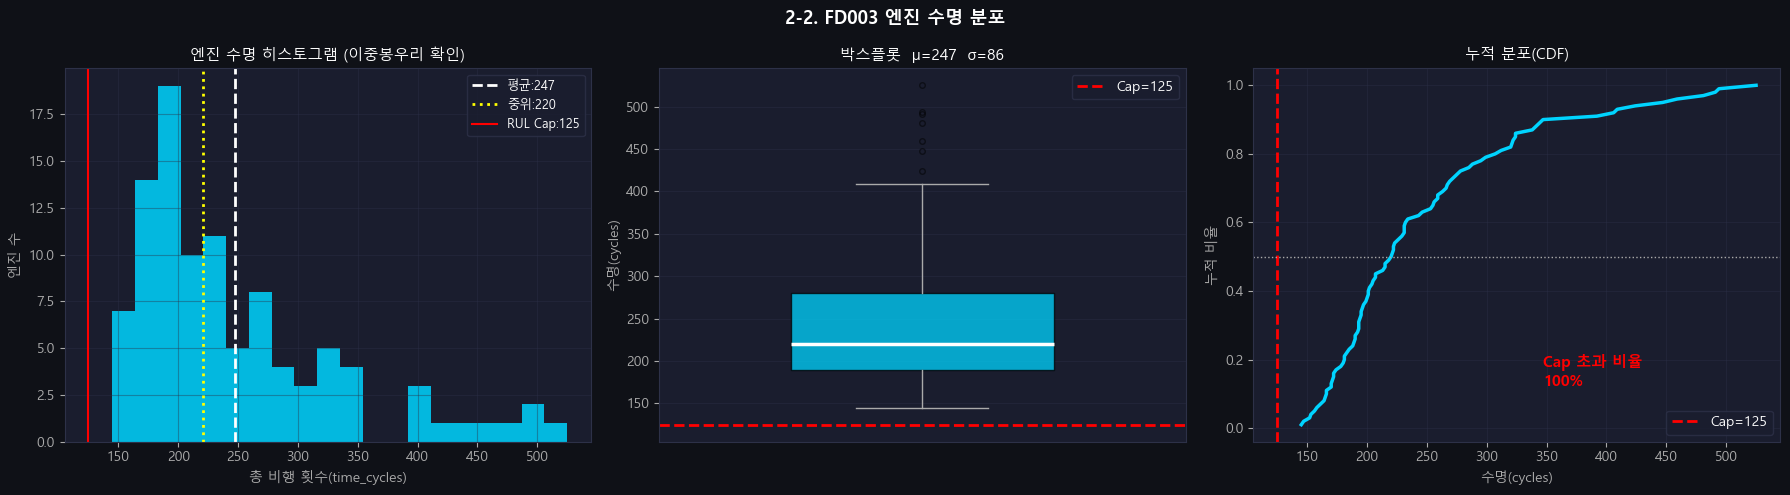


엔진 수명 통계:
  평균=247.2  중위=220.5  min=145  max=525
  Cap=125 초과 엔진: 100대 (100%)

📌 FD003: 수명 분포가 이중봉우리(bimodal)이면 두 고장 모드(HPC/Fan)의 수명 차이 가능성 시사


In [50]:
lifecycles = train_raw.groupby('unit_nr')['time_cycles'].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('2-2. FD003 엔진 수명 분포', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(lifecycles, bins=20, color=C[0], alpha=0.85, edgecolor='none')
ax.axvline(lifecycles.mean(),   color='white',  ls='--', lw=2, label=f'평균:{lifecycles.mean():.0f}')
ax.axvline(lifecycles.median(), color='yellow', ls=':',  lw=2, label=f'중위:{lifecycles.median():.0f}')
ax.axvline(RUL_CAP, color='red', ls='-', lw=1.5, label=f'RUL Cap:{RUL_CAP}')
ax.set_xlabel('총 비행 횟수(time_cycles)'); ax.set_ylabel('엔진 수')
ax.set_title('엔진 수명 히스토그램 (이중봉우리 확인)')
ax.legend(fontsize=9)

ax = axes[1]
bp = ax.boxplot(lifecycles, patch_artist=True, vert=True, widths=0.5,
                medianprops=dict(color='white',lw=2.5),
                whiskerprops=dict(color=GRAY), capprops=dict(color=GRAY),
                flierprops=dict(marker='o',color=GRAY,markersize=4,alpha=0.5))
bp['boxes'][0].set_facecolor(C[0]); bp['boxes'][0].set_alpha(0.75)
ax.axhline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.set_ylabel('수명(cycles)')
ax.set_title(f'박스플롯  μ={lifecycles.mean():.0f}  σ={lifecycles.std():.0f}')
ax.set_xticks([]); ax.legend()

ax = axes[2]
lc_sorted = np.sort(lifecycles)
cdf = np.arange(1, len(lc_sorted)+1)/len(lc_sorted)
ax.plot(lc_sorted, cdf, color=C[0], lw=2.5)
ax.axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
ax.axhline(0.5, color=GRAY, ls=':', lw=1)
pct_above = (lifecycles > RUL_CAP).mean()*100
ax.text(0.55, 0.15, f'Cap 초과 비율\n{pct_above:.0f}%', transform=ax.transAxes,
        fontsize=11, color='red', fontweight='bold')
ax.set_xlabel('수명(cycles)'); ax.set_ylabel('누적 비율')
ax.set_title('누적 분포(CDF)'); ax.legend()

plt.tight_layout(); plt.show()

print(f'\n엔진 수명 통계:')
print(f'  평균={lifecycles.mean():.1f}  중위={lifecycles.median():.1f}  min={lifecycles.min()}  max={lifecycles.max()}')
print(f'  Cap={RUL_CAP} 초과 엔진: {(lifecycles>RUL_CAP).sum()}대 ({pct_above:.0f}%)')
print(f'\n📌 FD003: 수명 분포가 이중봉우리(bimodal)이면 두 고장 모드(HPC/Fan)의 수명 차이 가능성 시사')

### 2-3. 센서 분포 & 이상치 (전처리 전)

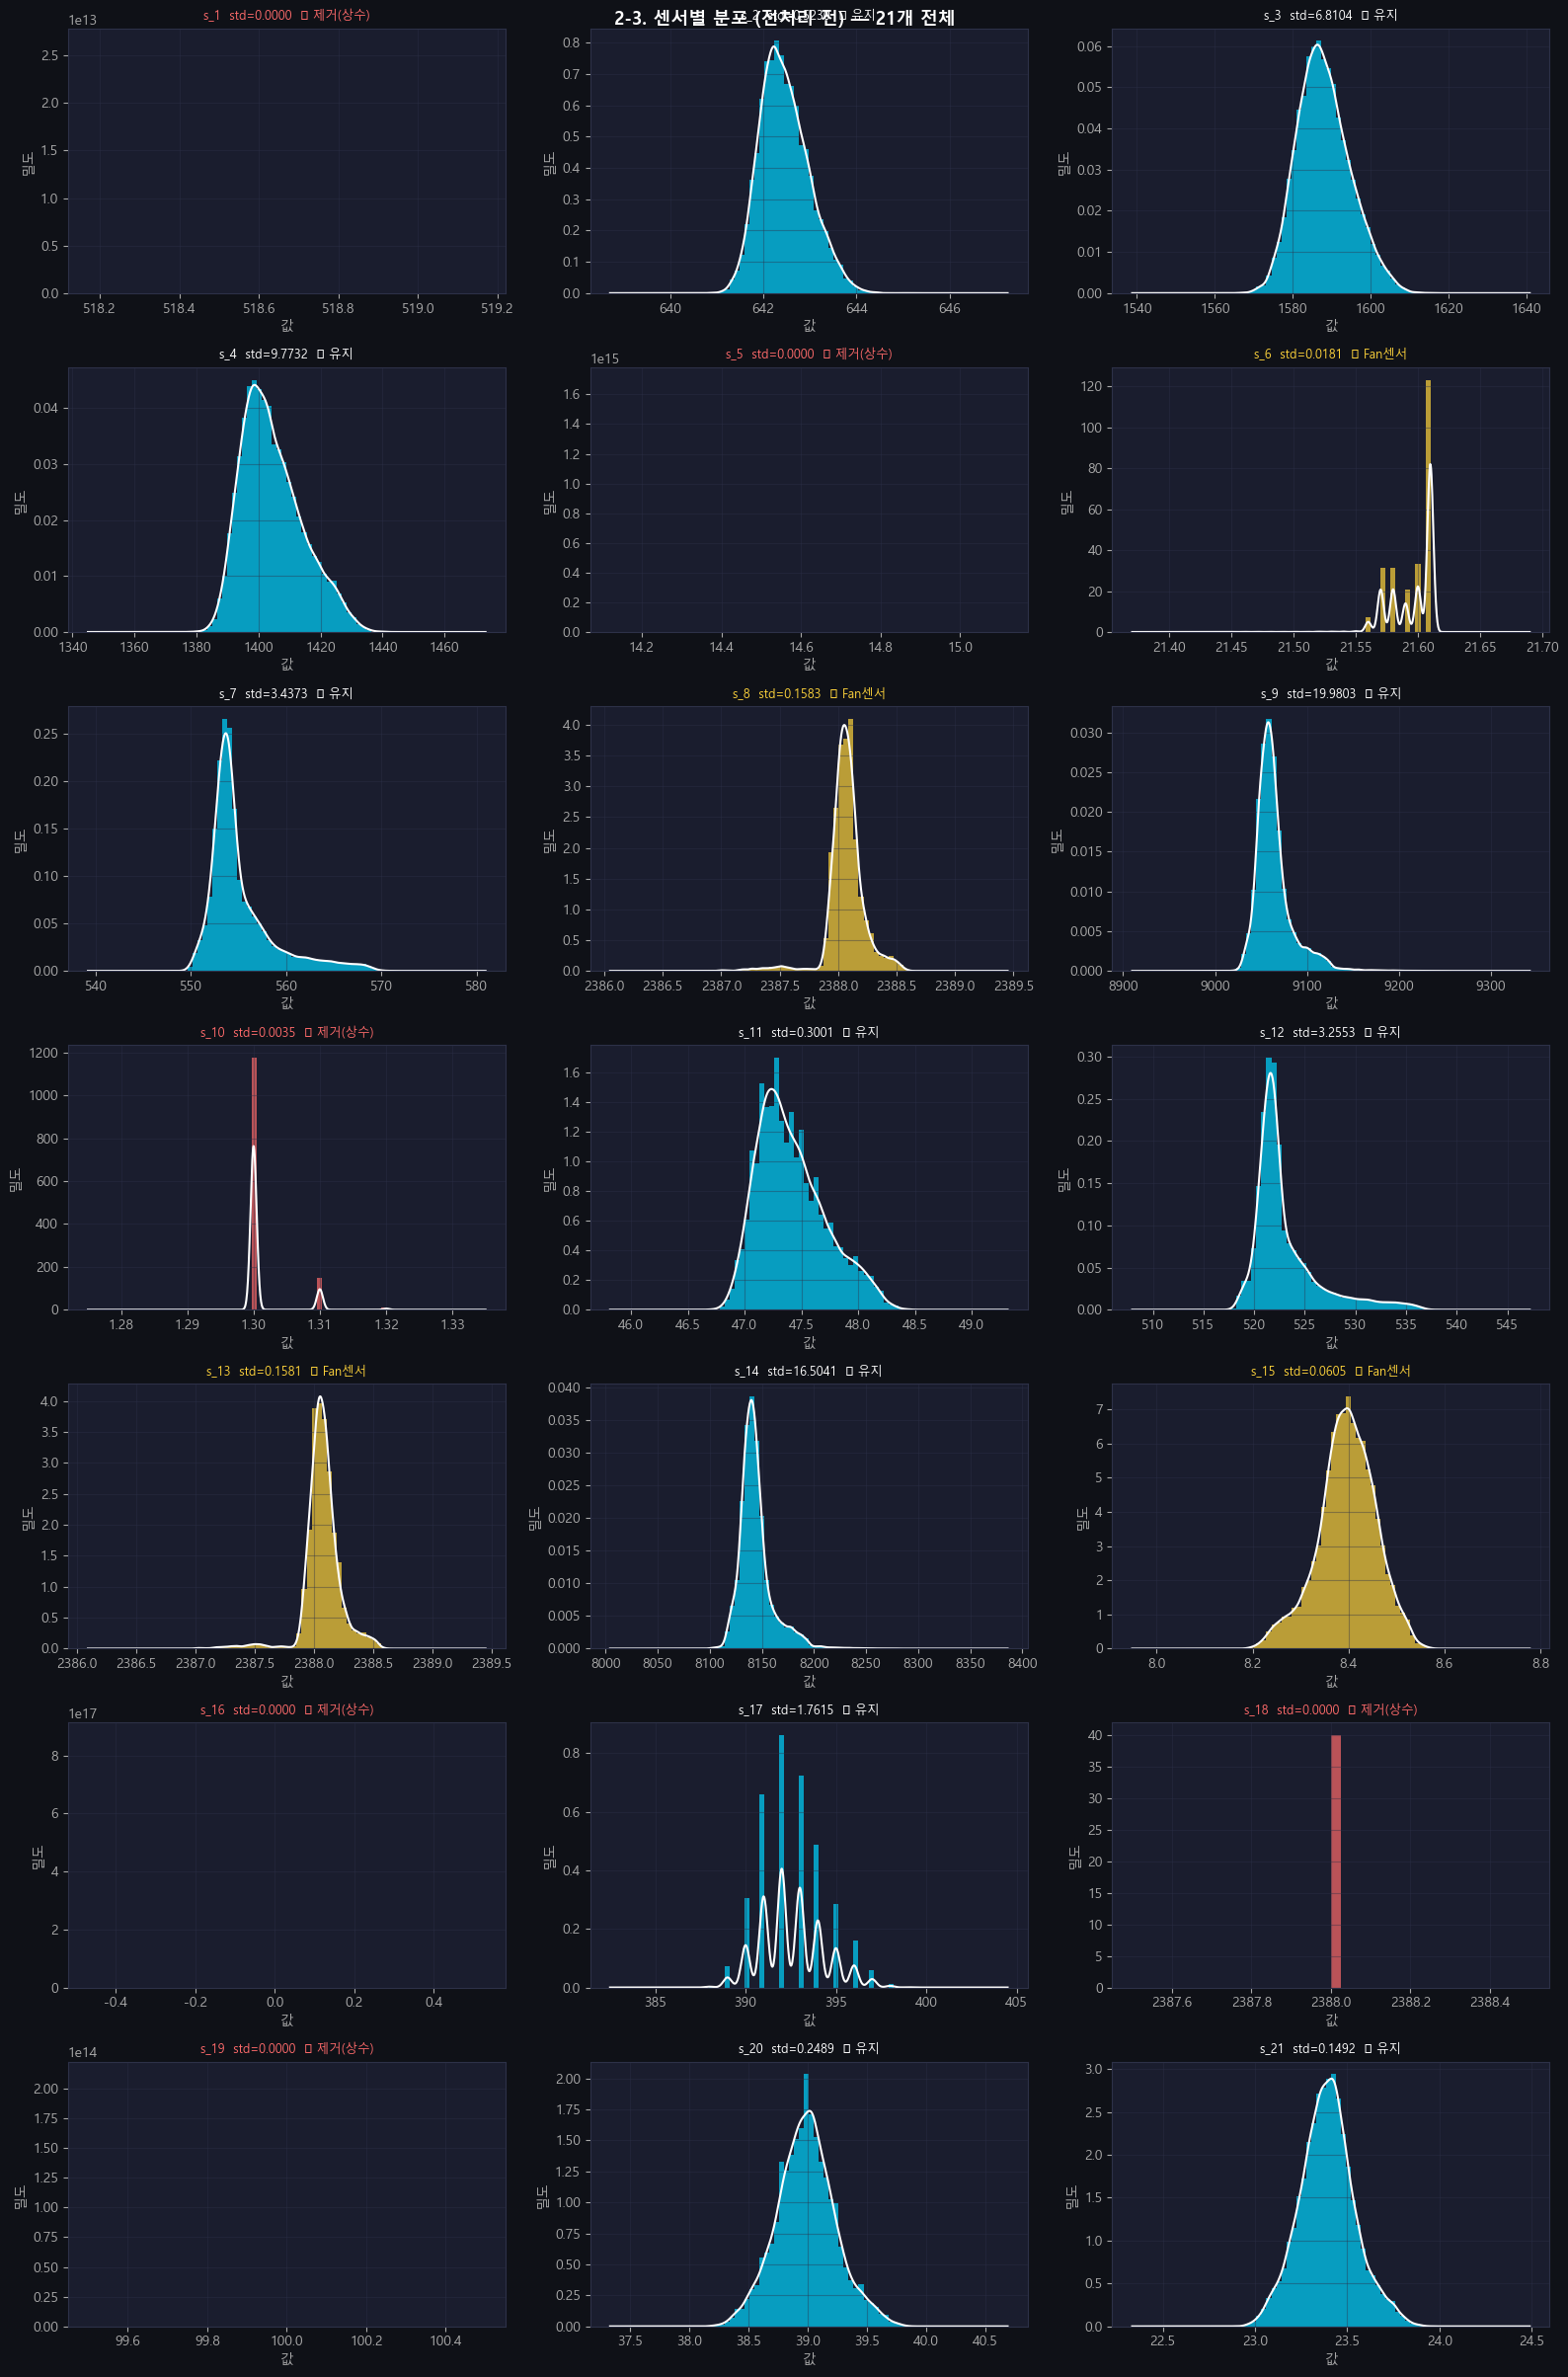

--- IQR 기준 이상치 탐지 ---


,센서,이상치 수,비율(%)
1,s_2,190,0.769
2,s_3,180,0.728
3,s_4,173,0.700
5,s_6,151,0.611
6,s_7,2188,8.851
7,s_8,1714,6.934
8,s_9,1844,7.460
9,s_10,2906,11.756
10,s_11,153,0.619
11,s_12,2276,9.207


In [51]:
n_cols, n_rows = 3, 7
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-3. 센서별 분포 (전처리 전) — 21개 전체', fontsize=13, fontweight='bold')

for ax, s in zip(axes.flat, SENSOR_COLS):
    data = train_raw[s].dropna()
    std_val = data.std()
    is_const = std_val < CONST_THR
    is_fan   = s in FAN_SENSORS
    color = C[1] if is_const else (C[3] if is_fan else C[0])
    ax.hist(data, bins=40, color=color, alpha=0.7, density=True, edgecolor='none')
    try: data.plot.kde(ax=ax, color='white', lw=1.5)
    except: pass
    label = '❌ 제거(상수)' if is_const else ('🔶 Fan센서' if is_fan else '✅ 유지')
    ax.set_title(f'{s}  std={std_val:.4f}  {label}', fontsize=9,
                 color=C[1] if is_const else (C[3] if is_fan else WHITE))
    ax.set_xlabel('값'); ax.set_ylabel('밀도')

for ax in axes.flat[len(SENSOR_COLS):]: ax.set_visible(False)
plt.tight_layout(); plt.show()

print('--- IQR 기준 이상치 탐지 ---')
outlier_rows = []
for s in SENSOR_COLS:
    Q1, Q3 = train_raw[s].quantile(0.25), train_raw[s].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((train_raw[s] < Q1-1.5*IQR)|(train_raw[s] > Q3+1.5*IQR)).sum()
    outlier_rows.append({'센서':s,'이상치 수':n_out,'비율(%)':round(n_out/len(train_raw)*100,3)})
out_df = pd.DataFrame(outlier_rows)
nonzero = out_df[out_df['이상치 수']>0]
if len(nonzero): display(nonzero)
else: print('✅ IQR 기준 이상치 없음 (시뮬레이션 데이터 특성)')

### 2-4. 센서 간 상관관계 히트맵 (전처리 전)

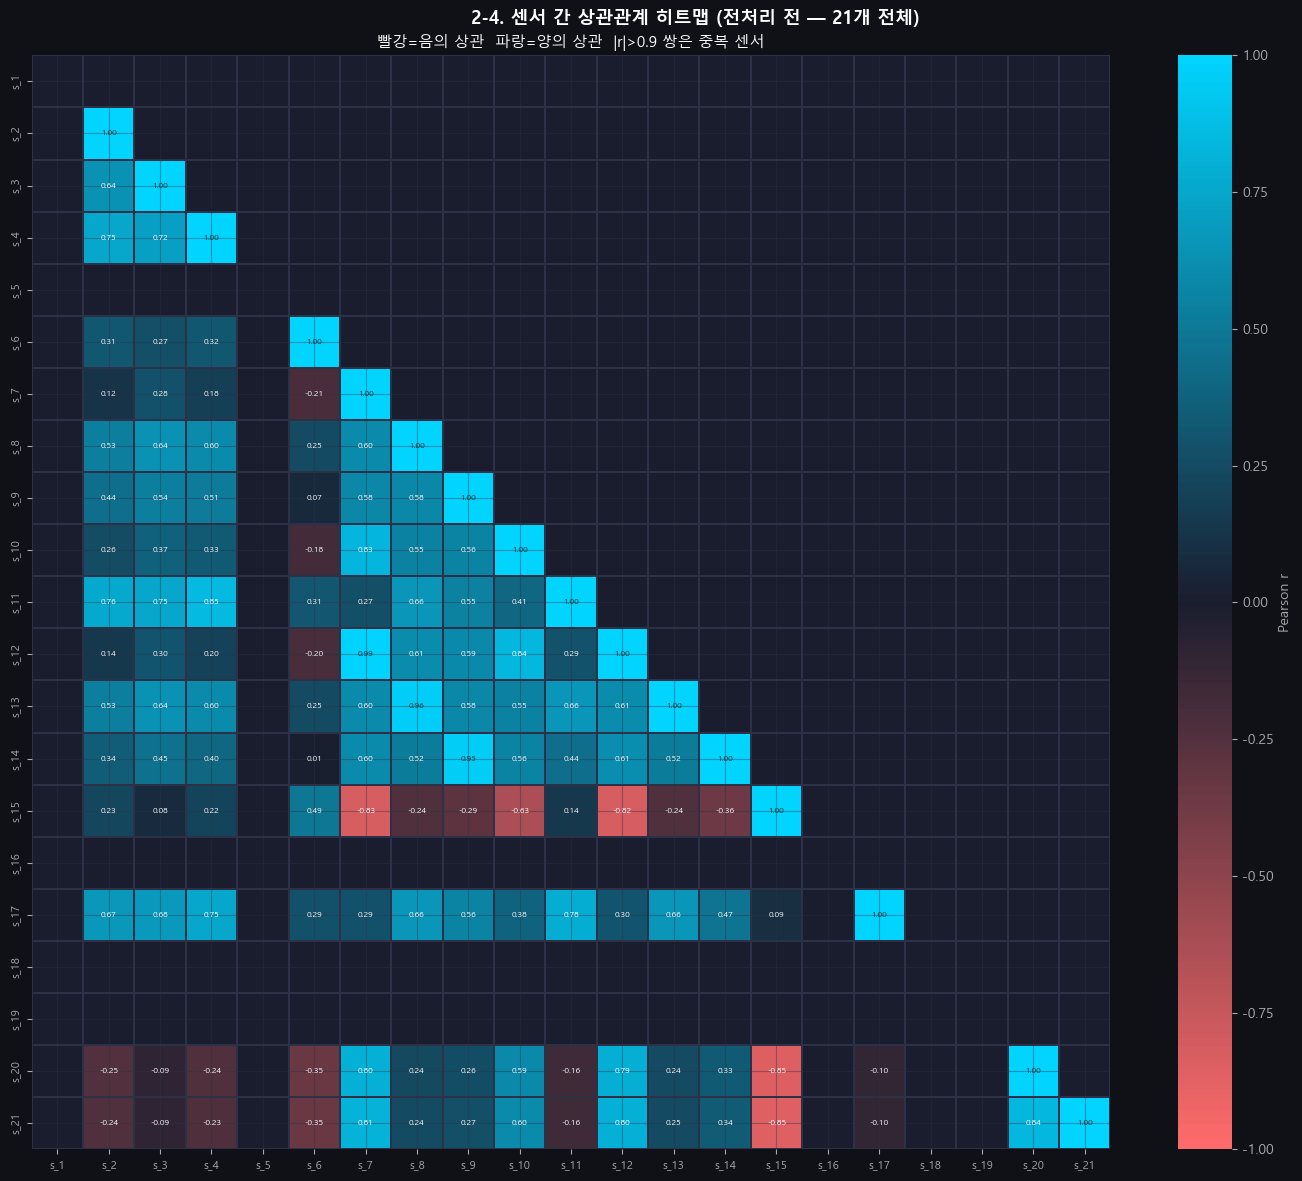

--- 고상관 센서 쌍 (|r| > 0.9): 3개 ---


,센서A,센서B,r
0,s_7,s_12,0.989
1,s_8,s_13,0.964
2,s_9,s_14,0.954


In [52]:
from matplotlib.colors import LinearSegmentedColormap
cmap_rg = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)

corr_before = train_raw[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle('2-4. 센서 간 상관관계 히트맵 (전처리 전 — 21개 전체)', fontsize=13, fontweight='bold')

mask = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=ax, mask=mask, cmap=cmap_rg, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size':6}, linewidths=0.3, linecolor=GRID,
            cbar_kws={'label':'Pearson r'})
ax.set_title('빨강=음의 상관  파랑=양의 상관  |r|>0.9 쌍은 중복 센서')
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

pairs = []
for i in range(len(SENSOR_COLS)):
    for j in range(i+1, len(SENSOR_COLS)):
        r = corr_before.iloc[i,j]
        if abs(r) > 0.9:
            pairs.append({'센서A':SENSOR_COLS[i],'센서B':SENSOR_COLS[j],'r':round(r,3)})
print(f'--- 고상관 센서 쌍 (|r| > 0.9): {len(pairs)}개 ---')
if pairs: display(pd.DataFrame(pairs))
else: print('  해당 없음')

### 2-5. 센서별 열화 트렌드 (전처리 전)

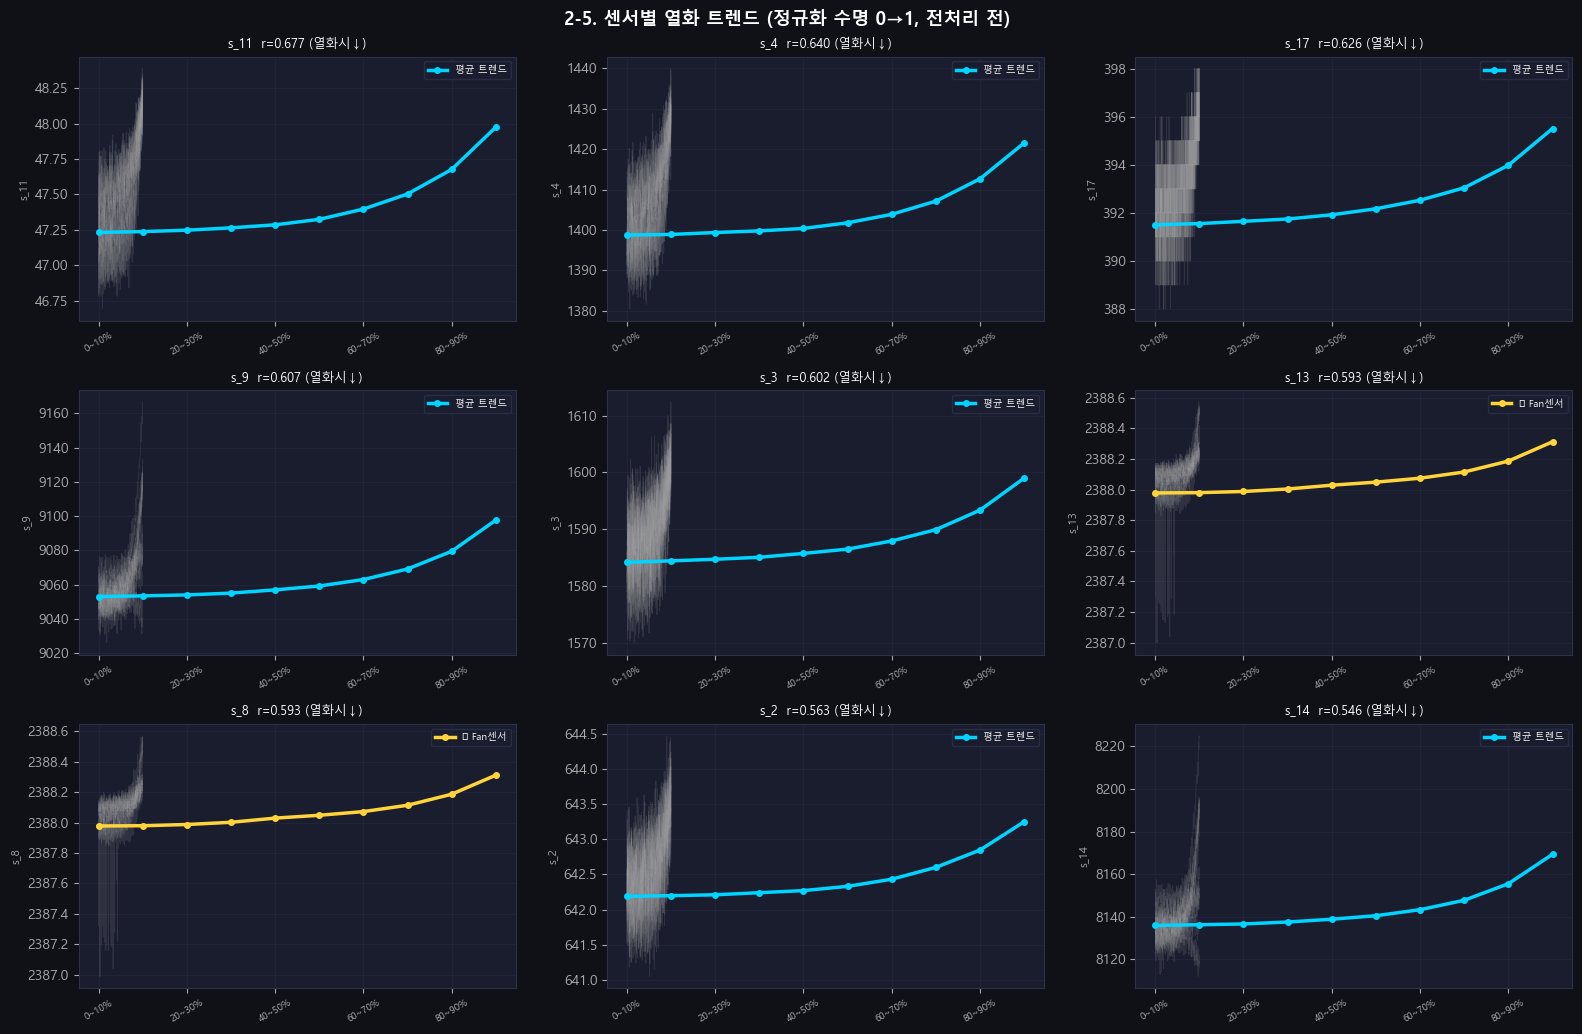

📌 r < 0: 엔진이 닳을수록 센서값 증가  |  r > 0: 감소
📌 노란색(🔶) = Fan 관련 센서 — FD001 대비 트렌드 변화 여부 주목


In [53]:
tr_trend = train_raw.copy()
mc = tr_trend.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_trend = tr_trend.join(mc, on='unit_nr')
tr_trend['norm_life'] = tr_trend['time_cycles']/tr_trend['max_c']

bins   = np.linspace(0, 1, 11)
labels = [f'{int(a*100)}~{int(b*100)}%' for a,b in zip(bins[:-1],bins[1:])]
tr_trend['life_bin'] = pd.cut(tr_trend['norm_life'], bins=bins, labels=labels)
trend_mean = tr_trend.groupby('life_bin', observed=True)[SENSOR_COLS].mean()

corr_with_life = tr_trend[SENSOR_COLS+['norm_life']].corr()['norm_life'][SENSOR_COLS]
trend_sensors  = corr_with_life[corr_with_life.abs()>0.1].sort_values(key=abs, ascending=False).index.tolist()
trend_sensors  = trend_sensors[:9]

n_cols = 3
n_rows = (len(trend_sensors)+n_cols-1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows*3.5))
fig.suptitle('2-5. 센서별 열화 트렌드 (정규화 수명 0→1, 전처리 전)', fontsize=13, fontweight='bold')

x_pos = range(len(labels))
sample_units = tr_trend['unit_nr'].unique()[:15]

for ax, s in zip(axes.flat, trend_sensors):
    is_fan = s in FAN_SENSORS
    for u in sample_units:
        sub = tr_trend[tr_trend['unit_nr']==u].sort_values('norm_life')
        ax.plot(sub['norm_life'], sub[s], color=GRAY, alpha=0.15, lw=0.6)
    color = C[3] if is_fan else C[0]
    ax.plot(x_pos, trend_mean[s].values, color=color, lw=2.5, marker='o', markersize=4,
            label=f'{"🔶 Fan센서" if is_fan else "평균 트렌드"}')
    r = corr_with_life[s]
    direction = '열화시↑' if r<0 else '열화시↓'
    ax.set_title(f'{s}  r={r:.3f} ({direction})', fontsize=9)
    ax.set_xticks(x_pos[::2])
    ax.set_xticklabels(labels[::2], rotation=30, fontsize=7)
    ax.set_ylabel(s, fontsize=8); ax.legend(fontsize=7)

for ax in axes.flat[len(trend_sensors):]: ax.set_visible(False)
plt.tight_layout(); plt.show()
print('📌 r < 0: 엔진이 닳을수록 센서값 증가  |  r > 0: 감소')
print('📌 노란색(🔶) = Fan 관련 센서 — FD001 대비 트렌드 변화 여부 주목')

### 2-6. RUL 상관계수 (전처리 전)

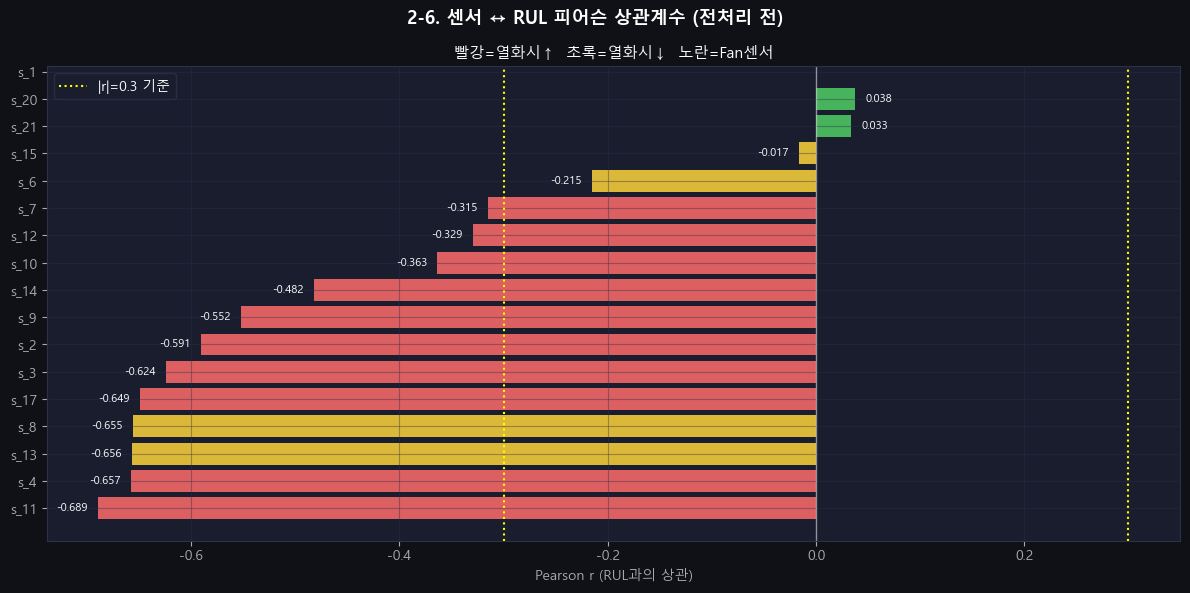

|r|>0.3 고상관 센서: 12개
  s_11: r=-0.689  🔵 HPC  Ps30 정적압력(psia)
  s_4: r=-0.657    T50 LPT 출구 온도(°R)
  s_13: r=-0.656  🔶 Fan  NRf 보정 팬 속도(rpm)
  s_8: r=-0.655  🔶 Fan  Nf 팬 속도(rpm)
  s_17: r=-0.649    htBleed 블리드 엔탈피
  s_3: r=-0.624  🔵 HPC  T30 HPC 출구 온도(°R)
  s_2: r=-0.591    T24 LPC 출구 온도(°R)
  s_9: r=-0.552  🔵 HPC  Nc 코어 속도(rpm)
  s_14: r=-0.482    NRc 보정 코어속도(rpm)
  s_10: r=-0.363    epr 엔진 압력비
  s_12: r=-0.329  🔵 HPC  phi 연료/Ps30 비율
  s_7: r=-0.315  🔵 HPC  P30 HPC 출구 압력(psia)


In [54]:
tr_rul = train_raw.copy()
mc = tr_rul.groupby('unit_nr')['time_cycles'].max().rename('max_c')
tr_rul = tr_rul.join(mc, on='unit_nr')
tr_rul['RUL'] = tr_rul['max_c'] - tr_rul['time_cycles']

rul_corr_before = tr_rul[SENSOR_COLS+['RUL']].corr()['RUL'][SENSOR_COLS].sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2-6. 센서 ↔ RUL 피어슨 상관계수 (전처리 전)', fontsize=13, fontweight='bold')

bar_colors = [C[3] if s in FAN_SENSORS else (C[1] if v<0 else C[2])
              for s, v in rul_corr_before.items()]
bars = ax.barh(rul_corr_before.index, rul_corr_before.values, color=bar_colors, alpha=0.85)
ax.axvline(0,    color='white', lw=1, alpha=0.5)
ax.axvline( 0.3, color='yellow', lw=1.5, ls=':', label='|r|=0.3 기준')
ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
ax.set_xlabel('Pearson r (RUL과의 상관)')
ax.set_title('빨강=열화시↑  초록=열화시↓  노란=Fan센서')
ax.legend()
for bar, val in zip(bars, rul_corr_before.values):
    ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout(); plt.show()

high_corr = rul_corr_before[rul_corr_before.abs()>0.3]
print(f'|r|>0.3 고상관 센서: {len(high_corr)}개')
for s, r in high_corr.sort_values(key=abs, ascending=False).items():
    tag = '🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '')
    print(f'  {s}: r={r:.3f}  {tag}  {SENSOR_DESC.get(s,"")[:30]}')

### 2-7. 시차상관관계 (Sensor → RUL, lag 0 ~ 15)

> **해석:** lag=k에서의 상관계수는 '현재 센서값이 k사이클 뒤의 RUL과 얼마나 관련되는가'를 의미.  
> FD003에서는 Fan 센서의 lag 패턴이 HPC 센서와 다를 수 있음 — 두 고장 모드의 조기 경보 타이밍 차이

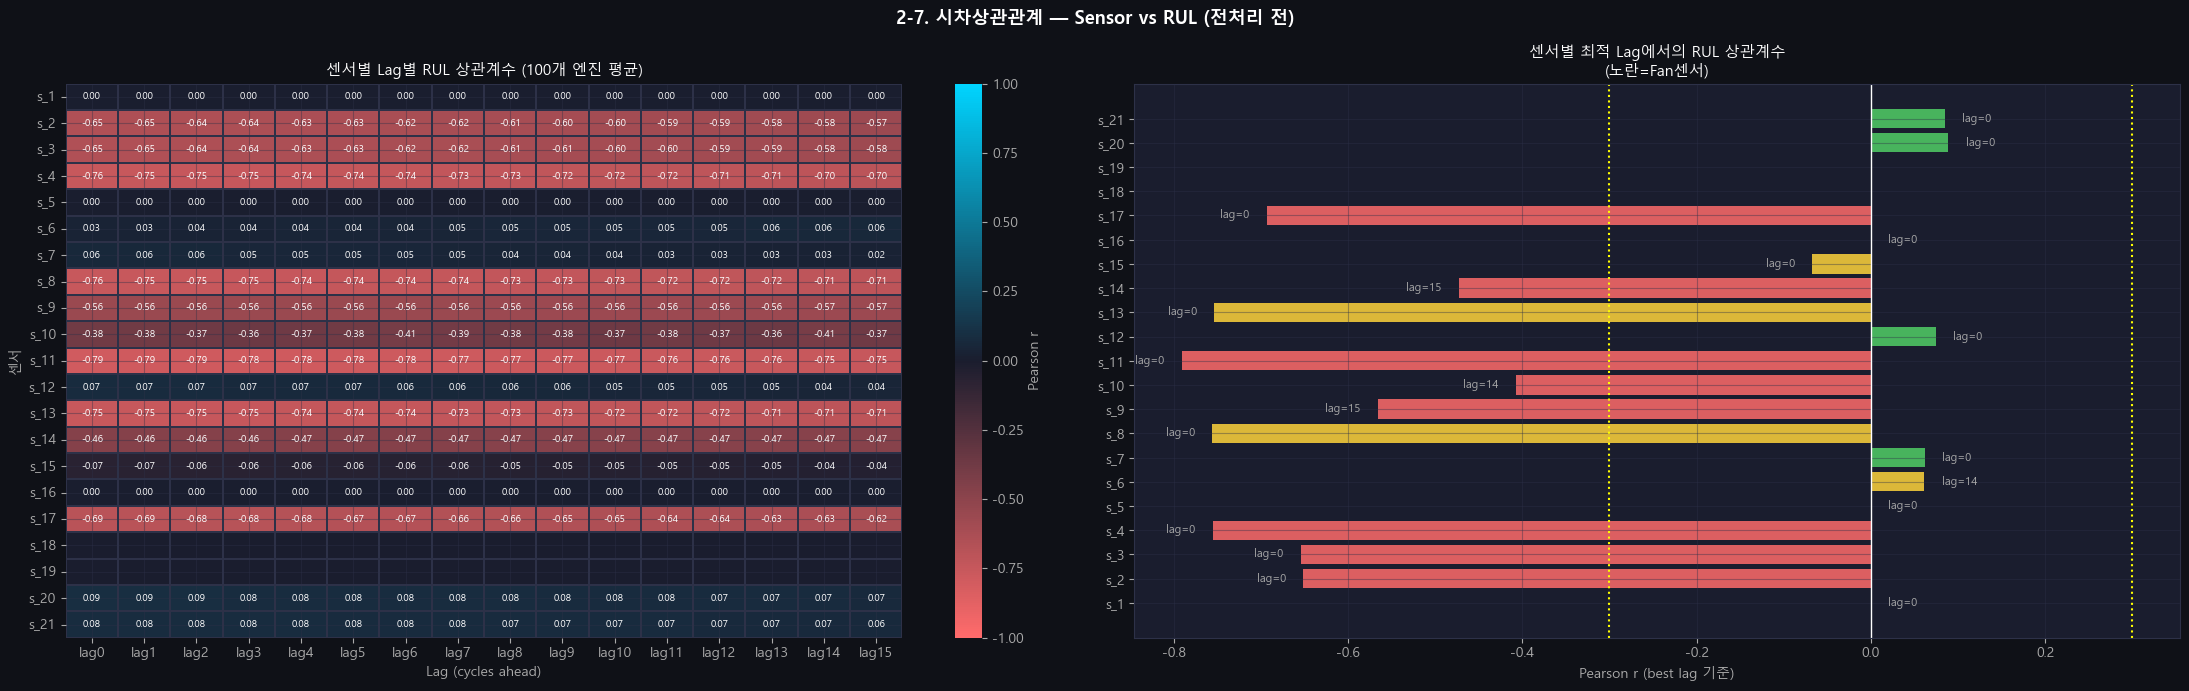

,최적 lag (cycles),상관계수 (r),조기경보 능력,센서 유형,센서 설명
센서,,,,,
s_1,0,0.0000,❌ 약함,🔶 Fan,T2 팬 입구 온도(°R)
s_2,0,-0.6511,✅ 강함,기타,T24 LPC 출구 온도(°R)
s_3,0,-0.6543,✅ 강함,🔵 HPC,T30 HPC 출구 온도(°R)
s_4,0,-0.7554,✅ 강함,기타,T50 LPT 출구 온도(°R)
s_5,0,0.0000,❌ 약함,기타,P2 팬 입구 압력(psia)
s_6,14,0.0611,❌ 약함,🔶 Fan,P15 바이패스 압력(psia)
s_7,0,0.0614,❌ 약함,🔵 HPC,P30 HPC 출구 압력(psia)
s_8,0,-0.7555,✅ 강함,🔶 Fan,Nf 팬 속도(rpm)
s_9,15,-0.5655,✅ 강함,🔵 HPC,Nc 코어 속도(rpm)


In [55]:
MAX_LAG = 15
LAGS    = list(range(0, MAX_LAG + 1))

lag_matrix = np.full((len(SENSOR_COLS), len(LAGS)), np.nan)

for si, s in enumerate(SENSOR_COLS):
    unit_lag_corrs = {lag: [] for lag in LAGS}
    for uid in tr_rul['unit_nr'].unique():
        udf    = tr_rul[tr_rul['unit_nr']==uid].sort_values('time_cycles')
        sensor = udf[s].values
        rul    = udf['RUL'].values
        for lag in LAGS:
            if len(sensor) > lag + 5:
                c = np.corrcoef(sensor[:len(sensor)-lag], rul[lag:])[0,1]
                if np.isfinite(c): unit_lag_corrs[lag].append(c)
    lag_matrix[si] = [np.mean(unit_lag_corrs[l]) if unit_lag_corrs[l] else np.nan for l in LAGS]

lag_df = pd.DataFrame(lag_matrix, index=SENSOR_COLS, columns=[f'lag{l}' for l in LAGS])

best_lag_idx, best_lag_corr = [], []
for i in range(len(SENSOR_COLS)):
    row = lag_matrix[i]
    if np.all(np.isnan(row)):
        best_lag_idx.append(0); best_lag_corr.append(np.nan)
    else:
        idx = int(np.nanargmax(np.abs(row)))
        best_lag_idx.append(idx); best_lag_corr.append(float(row[idx]))

best_lag_corr_plot = [v if np.isfinite(v) else 0.0 for v in best_lag_corr]

cmap_lag = LinearSegmentedColormap.from_list('lag', ['#ff6b6b','#1a1d2e','#00d4ff'], N=256)

fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.suptitle('2-7. 시차상관관계 — Sensor vs RUL (전처리 전)', fontsize=13, fontweight='bold')

sns.heatmap(lag_df, ax=axes[0], cmap=cmap_lag, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label':'Pearson r'})
axes[0].set_title('센서별 Lag별 RUL 상관계수 (100개 엔진 평균)')
axes[0].set_xlabel('Lag (cycles ahead)'); axes[0].set_ylabel('센서')

bar_colors = [GRAY if not np.isfinite(v) else (C[3] if SENSOR_COLS[i] in FAN_SENSORS
              else (C[1] if v<0 else C[2])) for i, v in enumerate(best_lag_corr)]
bars = axes[1].barh(SENSOR_COLS, best_lag_corr_plot, color=bar_colors, alpha=0.85)
axes[1].axvline(0, color='white', lw=1)
axes[1].axvline(0.3, color='yellow', lw=1.5, ls=':')
axes[1].axvline(-0.3, color='yellow', lw=1.5, ls=':')
for bar, li, v in zip(bars, best_lag_idx, best_lag_corr):
    if not np.isfinite(v): continue
    x = bar.get_width()
    axes[1].text(x+(0.02 if x>=0 else -0.02), bar.get_y()+bar.get_height()/2,
                 f'lag={LAGS[li]}', va='center', ha='left' if x>=0 else 'right', fontsize=8, color=GRAY)
axes[1].set_title('센서별 최적 Lag에서의 RUL 상관계수\n(노란=Fan센서)')
axes[1].set_xlabel('Pearson r (best lag 기준)')
plt.tight_layout(); plt.show()

lag_summary = pd.DataFrame({
    '최적 lag (cycles)': [LAGS[i] for i in best_lag_idx],
    '상관계수 (r)'     : [round(v,4) if np.isfinite(v) else np.nan for v in best_lag_corr],
    '조기경보 능력'    : ['⬜ 상수센서' if not np.isfinite(v)
                         else ('✅ 강함' if abs(v)>=0.5 else ('🔶 보통' if abs(v)>=0.3 else '❌ 약함'))
                         for v in best_lag_corr],
    '센서 유형'        : ['🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '기타')
                         for s in SENSOR_COLS],
    '센서 설명'        : [SENSOR_DESC.get(s,s) for s in SENSOR_COLS],
}, index=SENSOR_COLS)
lag_summary.index.name = '센서'
display(lag_summary)

### 2-8. Mann-Kendall 트렌드 검정 (전처리 전)

> **원리:** 비모수 단조 트렌드 검정 — **유의 엔진 비율 ≥ 70%** → 열화 신호 안정 보유

In [56]:
print('=== 2-8. Mann-Kendall 트렌드 검정 (유의 엔진 비율) ===')

mk_rows = []
for s in SENSOR_COLS:
    sig_up, sig_dn, total = 0, 0, 0
    for uid in tr_rul['unit_nr'].unique():
        vals = tr_rul[tr_rul['unit_nr']==uid].sort_values('time_cycles')[s].values
        if len(vals) < 5: continue
        tau, p = kendalltau(np.arange(len(vals)), vals)
        total += 1
        if p < 0.05:
            if tau > 0: sig_up += 1
            else:       sig_dn += 1
    sig_pct = (sig_up+sig_dn)/total*100 if total else 0
    mk_rows.append({'센서':s, '상승 유의':sig_up, '하강 유의':sig_dn,
                    '유의 비율(%)':round(sig_pct,1),
                    '트렌드 방향':'↑ 증가' if sig_up>sig_dn else '↓ 감소',
                    '유용성':'✅ 유용' if sig_pct>=70 else '❌ 미약',
                    '센서 유형':'🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '기타')})

mk_df = pd.DataFrame(mk_rows).set_index('센서')
display(mk_df.style.background_gradient(subset=['유의 비율(%)'], cmap='YlGn'))
useful_mk = mk_df[mk_df['유용성']=='✅ 유용'].index.tolist()
print(f'\n유용 센서 (유의 비율≥70%): {len(useful_mk)}개')
print(f'  {useful_mk}')

=== 2-8. Mann-Kendall 트렌드 검정 (유의 엔진 비율) ===


,상승 유의,하강 유의,유의 비율(%),트렌드 방향,유용성,센서 유형
센서,,,,,,
s_1,0,0,0.000000,↓ 감소,❌ 미약,🔶 Fan
s_2,100,0,100.000000,↑ 증가,✅ 유용,기타
s_3,100,0,100.000000,↑ 증가,✅ 유용,🔵 HPC
s_4,100,0,100.000000,↑ 증가,✅ 유용,기타
s_5,0,0,0.000000,↓ 감소,❌ 미약,기타
s_6,27,23,50.000000,↑ 증가,❌ 미약,🔶 Fan
s_7,44,56,100.000000,↓ 감소,✅ 유용,🔵 HPC
s_8,100,0,100.000000,↑ 증가,✅ 유용,🔶 Fan
s_9,82,15,97.000000,↑ 증가,✅ 유용,🔵 HPC



유용 센서 (유의 비율≥70%): 14개
  ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']


---
## 3. 결정 1 — 상수 센서 제거 (Fan 센서 재검토)

**FD001 대비 주의:** FD003에는 Fan 열화가 포함되어 FD001에서 제거한 Fan 관련 센서가 유효할 수 있음.  
- `s_1(T2)`, `s_5(P2)`, `s_6(P15)` — Fan 모듈 직접 연관  
- 기준: 전체 std < 0.01 → 제거 (FD001과 동일한 기준 적용 후 결과 비교)

=== 결정 1 — 상수 센서 제거 ===
제거 대상 (std<0.01): ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']  (6개)
최종 유지:                   ['s_2', 's_3', 's_4', 's_6', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']  (15개)

📌 FD001 대비 비교:
  FD001 제거 목록: ['s_1', 's_5', 's_6', 's_10', 's_16', 's_18', 's_19']
  FD003 제거 목록: ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']
  Fan 센서 복원:   ['s_6']


,std,판정,유형
센서,,,
s_1,0.000000e+00,❌ 제거,🔶 Fan
s_2,5.230311e-01,✅ 유지,기타
s_3,6.810418e+00,✅ 유지,🔵 HPC
s_4,9.773178e+00,✅ 유지,기타
s_5,3.552786e-15,❌ 제거,기타
s_6,1.811600e-02,✅ 유지,🔶 Fan
s_7,3.437343e+00,✅ 유지,🔵 HPC
s_8,1.582849e-01,✅ 유지,🔶 Fan
s_9,1.998029e+01,✅ 유지,🔵 HPC



✅ 상수 센서 제거 완료: 21개 → 15개


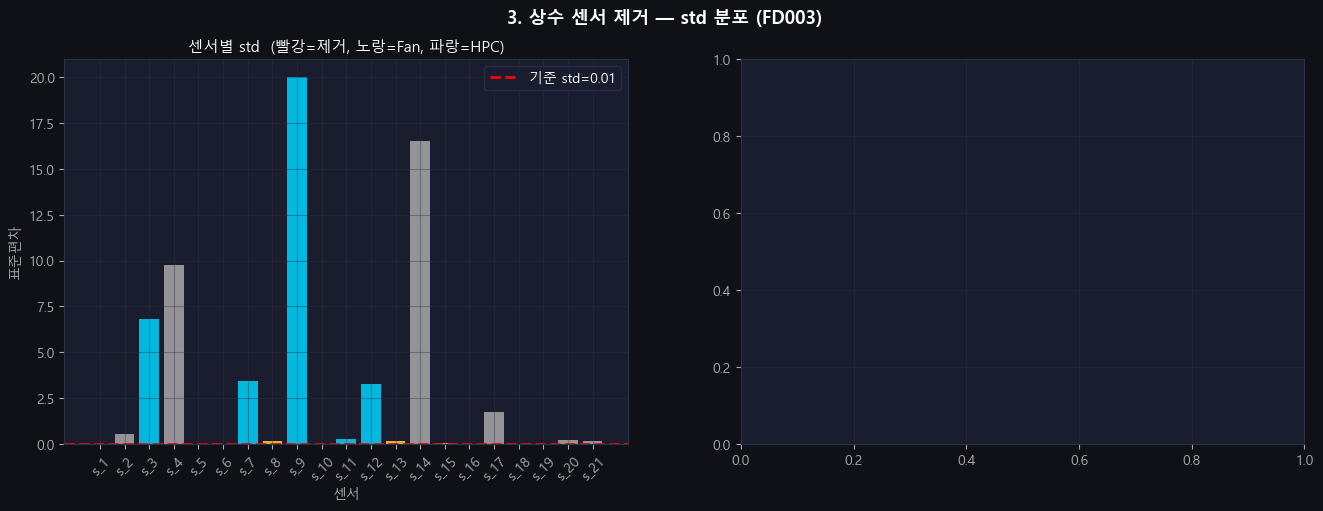

In [57]:
# FD001에서 제거된 센서 목록 (비교 기준)
FD001_REMOVED = ['s_1','s_5','s_6','s_10','s_16','s_18','s_19']  # 실제 FD001 결과에 맞게 조정

train_std = train_raw[SENSOR_COLS].std()
const_sensors = train_std[train_std < CONST_THR].index.tolist()

# Fan 센서 중 이번에 유지되는 것 확인
fan_recovered = [s for s in FD001_REMOVED if s in FAN_SENSORS and s not in const_sensors]

REMOVE_SENSORS = sorted(const_sensors, key=lambda x: int(x.split('_')[1]))
USEFUL_SENSORS = sorted([s for s in SENSOR_COLS if s not in REMOVE_SENSORS],
                        key=lambda x: int(x.split('_')[1]))

print('=== 결정 1 — 상수 센서 제거 ===')
print(f'제거 대상 (std<{CONST_THR}): {REMOVE_SENSORS}  ({len(REMOVE_SENSORS)}개)')
print(f'최종 유지:                   {USEFUL_SENSORS}  ({len(USEFUL_SENSORS)}개)')
print(f'\n📌 FD001 대비 비교:')
print(f'  FD001 제거 목록: {FD001_REMOVED}')
print(f'  FD003 제거 목록: {REMOVE_SENSORS}')
print(f'  Fan 센서 복원:   {fan_recovered if fan_recovered else "없음 (Fan센서도 상수 유지됨)"}')

# std 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('3. 상수 센서 제거 — std 분포 (FD003)', fontsize=13, fontweight='bold')

colors_bar = []
for s in SENSOR_COLS:
    if s in REMOVE_SENSORS:  colors_bar.append(C[1])   # 제거=빨강
    elif s in FAN_SENSORS:   colors_bar.append(C[3])   # Fan=노랑
    elif s in HPC_SENSORS:   colors_bar.append(C[0])   # HPC=파랑
    else:                    colors_bar.append(GRAY)

axes[0].bar(SENSOR_COLS, train_std[SENSOR_COLS], color=colors_bar, alpha=0.85)
axes[0].axhline(CONST_THR, color='red', ls='--', lw=2, label=f'기준 std={CONST_THR}')
axes[0].set_xlabel('센서'); axes[0].set_ylabel('표준편차')
axes[0].set_title('센서별 std  (빨강=제거, 노랑=Fan, 파랑=HPC)')
axes[0].tick_params(axis='x', rotation=45); axes[0].legend()

summary_data = pd.DataFrame({
    '센서':SENSOR_COLS,
    'std':train_std[SENSOR_COLS].values,
    '판정':['❌ 제거' if s in REMOVE_SENSORS else '✅ 유지' for s in SENSOR_COLS],
    '유형':['🔶 Fan' if s in FAN_SENSORS else ('🔵 HPC' if s in HPC_SENSORS else '기타') for s in SENSOR_COLS]
}).set_index('센서')
display(summary_data)

# 원본에 적용
train_s1 = train_raw.drop(columns=REMOVE_SENSORS)
test_s1  = test_raw.drop( columns=REMOVE_SENSORS)
print(f'\n✅ 상수 센서 제거 완료: {len(SENSOR_COLS)}개 → {len(USEFUL_SENSORS)}개')

---
## 4. RUL 레이블 생성 & Cap 적용

**FD003 주목:** 두 고장 모드의 수명 분포 차이가 있을 경우 고장 모드별 cap을 검토  
기본값: cap=125 (FD001과 동일)

✅ RUL 레이블 생성 완료  |  cap=125
   Train RUL 범위: 0 ~ 125
   Test  RUL 범위: 6 ~ 145


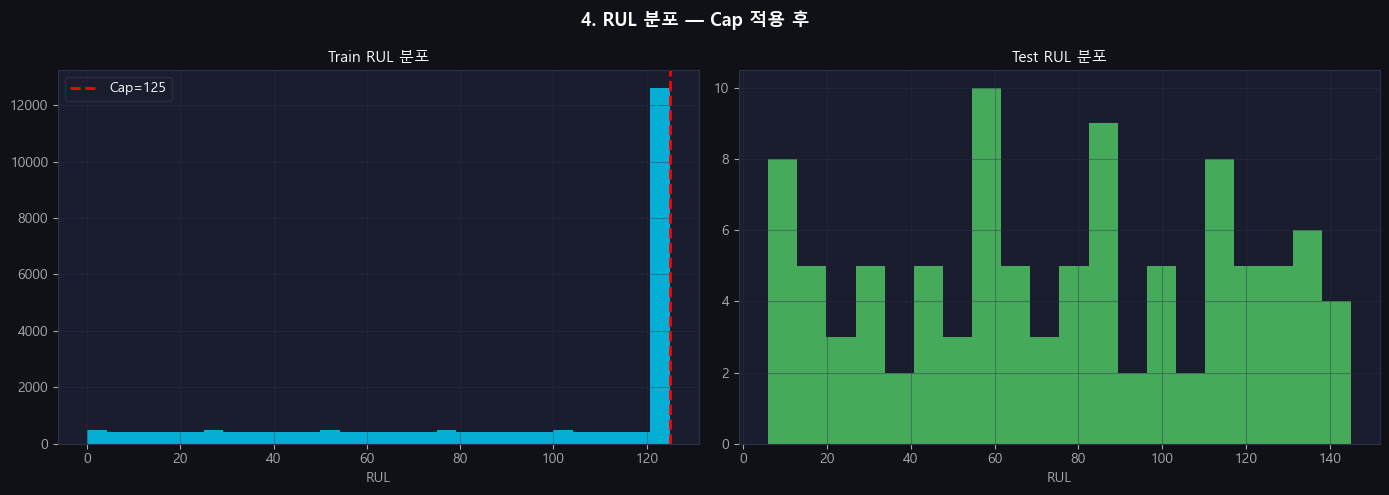

In [58]:
def add_rul(df, cap=None):
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL'] = df['max_c'] - df['time_cycles']
    if cap: df['RUL'] = df['RUL'].clip(upper=cap)
    return df.drop(columns='max_c')

train_s2 = add_rul(train_s1, cap=RUL_CAP)

# 테스트 RUL (마지막 행 + 실제 RUL)
test_last = test_s1.groupby('unit_nr').last().reset_index()
test_last['RUL'] = rul_df['RUL'].values

print(f'✅ RUL 레이블 생성 완료  |  cap={RUL_CAP}')
print(f'   Train RUL 범위: {train_s2["RUL"].min():.0f} ~ {train_s2["RUL"].max():.0f}')
print(f'   Test  RUL 범위: {test_last["RUL"].min():.0f} ~ {test_last["RUL"].max():.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('4. RUL 분포 — Cap 적용 후', fontsize=13, fontweight='bold')
axes[0].hist(train_s2['RUL'], bins=30, color=C[0], alpha=0.8, edgecolor='none')
axes[0].axvline(RUL_CAP, color='red', ls='--', lw=2, label=f'Cap={RUL_CAP}')
axes[0].set_title('Train RUL 분포'); axes[0].set_xlabel('RUL'); axes[0].legend()
axes[1].hist(test_last['RUL'], bins=20, color=C[2], alpha=0.8, edgecolor='none')
axes[1].set_title('Test RUL 분포'); axes[1].set_xlabel('RUL')
plt.tight_layout(); plt.show()

---
## 5. [FD003 신규] 고장 모드 클러스터링 (KMeans k=2)

**목적:** FD003에는 HPC 열화 / Fan 열화 두 고장 모드가 혼재.  
Ground-truth 레이블이 없으므로 비지도 학습으로 암묵적 식별.  

**전략:**  
1. 엔진별 마지막 `SLOPE_WINDOW` 사이클의 **센서 slope + mean** 추출  
2. KMeans(k=2)로 클러스터링 → silhouette score 검증  
3. 클러스터별 HPC/Fan 센서 평균 비교 → 고장 유형 해석  
4. `fault_mode_cluster` 컬럼으로 추가 (ML/DL 피처)

> silhouette score < 0.2이면 클러스터링 효과 미약 → fault_mode_cluster 미사용 결정 가능

### 5-1. 엔진별 열화 피처 추출

In [59]:
def compute_engine_slope_features(df, sensors, slope_window=30):
    """엔진별 마지막 N 사이클의 센서 slope + mean 추출"""
    feats = []
    for uid in df['unit_nr'].unique():
        sub  = df[df['unit_nr']==uid].sort_values('time_cycles')
        last = sub.iloc[-slope_window:] if len(sub)>=slope_window else sub
        row  = {'unit_nr': uid}
        for s in sensors:
            vals = last[s].values
            x    = np.arange(len(vals))
            slope = np.polyfit(x, vals, 1)[0] if len(vals)>1 else 0.0
            row[f'{s}_slope'] = slope
            row[f'{s}_mean']  = vals.mean()
        feats.append(row)
    return pd.DataFrame(feats).set_index('unit_nr')

feat_df = compute_engine_slope_features(train_s2, USEFUL_SENSORS, slope_window=SLOPE_WINDOW)

print(f'✅ 엔진별 열화 피처 추출 완료')
print(f'   shape: {feat_df.shape}  (엔진 수 × 피처 수)')
print(f'   피처 수: {feat_df.shape[1]}  ({len(USEFUL_SENSORS)} 센서 × 2 통계 [slope, mean])')
display(feat_df.head(3))

✅ 엔진별 열화 피처 추출 완료
   shape: (100, 30)  (엔진 수 × 피처 수)
   피처 수: 30  (15 센서 × 2 통계 [slope, mean])


,s_2_slope,s_2_mean,s_3_slope,s_3_mean,s_4_slope,s_4_mean,s_6_slope,s_6_mean,s_7_slope,s_7_mean,...,s_14_slope,s_14_mean,s_15_slope,s_15_mean,s_17_slope,s_17_mean,s_20_slope,s_20_mean,s_21_slope,s_21_mean
unit_nr,,,,,,,,,,,,,,,,,,,,,
1,0.020961,643.454,0.201869,1597.584000,0.271942,1425.046,-5.190677e-16,21.610000,-0.028554,551.954333,...,-0.125330,8149.350667,0.001250,8.499277,0.088098,395.666667,-0.010465,38.514000,-0.002273,23.120937
2,0.024082,642.955,0.293517,1597.735333,0.576839,1418.159,5.784205e-05,21.579333,0.239713,564.901667,...,0.824610,8177.329333,-0.001740,8.267260,0.090100,395.166667,0.012654,39.468667,0.006302,23.700073
3,0.012665,643.485,0.138761,1597.791000,0.382334,1423.845,-5.190677e-16,21.610000,-0.047210,552.162333,...,0.357733,8156.475000,0.000723,8.495817,0.070300,395.266667,-0.010681,38.537667,-0.002304,23.134077


### 5-2. KMeans k=2 클러스터링 & Silhouette 검증

In [60]:
# Standardize
scaler_fault = StandardScaler()
feat_scaled  = scaler_fault.fit_transform(feat_df)

# Silhouette score for k=2,3,4
print('=== Silhouette Score 비교 ===')
sil_scores = {}
for k in [2, 3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(feat_scaled)
    sil = silhouette_score(feat_scaled, labels)
    sil_scores[k] = sil
    print(f'  k={k}: silhouette={sil:.4f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\n  최적 k: {best_k}  (silhouette={sil_scores[best_k]:.4f})')

USE_FAULT_CLUSTER = sil_scores[2] >= 0.2
print(f'  k=2 실루엣={sil_scores[2]:.4f}  → '
      f'{"✅ fault_mode_cluster 피처 사용" if USE_FAULT_CLUSTER else "⚠️ 클러스터링 효과 미약 — 피처 사용 재검토"}')

# Final KMeans with k=2
kmeans_fault = KMeans(n_clusters=N_FAULT_MODES, random_state=42, n_init=20)
cluster_labels = kmeans_fault.fit_predict(feat_scaled)
cluster_map    = dict(zip(feat_df.index, cluster_labels.tolist()))

# 클러스터 크기
unique, counts = np.unique(cluster_labels, return_counts=True)
print(f'\n  클러스터 분포:')
for u, c in zip(unique, counts):
    print(f'    Cluster {u}: {c}개 엔진 ({c/len(cluster_labels)*100:.1f}%)')

=== Silhouette Score 비교 ===
  k=2: silhouette=0.4691
  k=3: silhouette=0.4215
  k=4: silhouette=0.3591

  최적 k: 2  (silhouette=0.4691)
  k=2 실루엣=0.4691  → ✅ fault_mode_cluster 피처 사용

  클러스터 분포:
    Cluster 0: 44개 엔진 (44.0%)
    Cluster 1: 56개 엔진 (56.0%)


### 5-3. 클러스터 해석 — HPC vs Fan 열화

=== 5-3. 클러스터별 센서 평균 비교 — 고장 유형 해석 ===


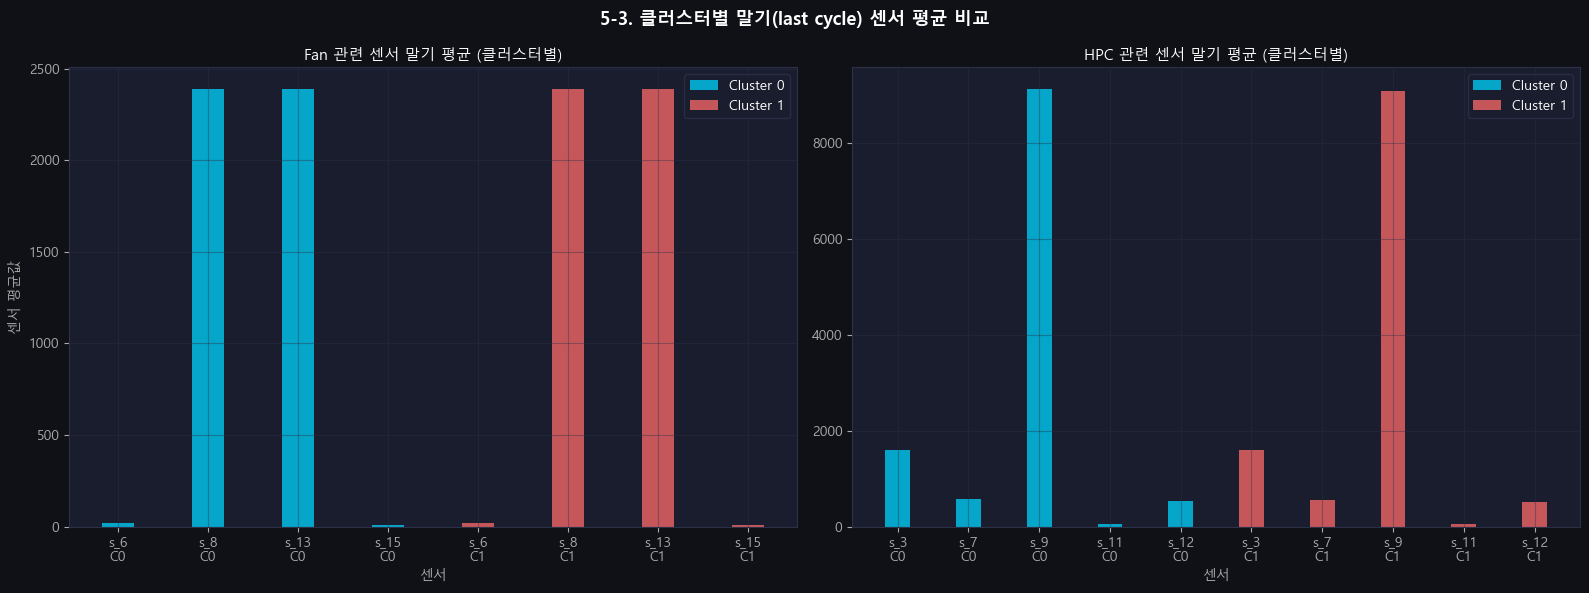


클러스터별 엔진 평균 수명:


,mean,std,min,max
cluster,,,,
0,304.659091,94.330183,190,525
1,202.053571,42.305564,145,341



📌 해석 방법:
  Fan 관련 센서(s_8 Nf, s_13 NRf, s_6 P15 등)에서 클러스터 간 차이가 크면
  → 해당 클러스터 = Fan 열화 그룹
  HPC 관련 센서(s_3 T30, s_7 P30, s_9 Nc 등)에서 차이가 크면
  → 해당 클러스터 = HPC 열화 그룹

⚠️ 아래 해석은 예시입니다. 위 시각화 결과 보고 CLUSTER_LABEL 수정 필요:
  {0: 'HPC열화추정', 1: 'Fan열화추정'}


In [61]:
print('=== 5-3. 클러스터별 센서 평균 비교 — 고장 유형 해석 ===')

# 각 엔진의 마지막 사이클 센서값
last_cycles = train_s2.groupby('unit_nr')[USEFUL_SENSORS].last()
last_cycles['cluster'] = last_cycles.index.map(cluster_map)

cluster_sensor_mean = last_cycles.groupby('cluster')[USEFUL_SENSORS].mean()

# HPC / Fan 센서 평균 차이
useful_fan = [s for s in FAN_SENSORS if s in USEFUL_SENSORS]
useful_hpc = [s for s in HPC_SENSORS if s in USEFUL_SENSORS]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('5-3. 클러스터별 말기(last cycle) 센서 평균 비교', fontsize=13, fontweight='bold')

for ci in range(N_FAULT_MODES):
    c_data = cluster_sensor_mean.loc[ci]

    # Fan 센서
    fan_vals = [c_data.get(s, np.nan) for s in useful_fan]
    axes[0].bar([f'{s}\nC{ci}' for s in useful_fan], fan_vals,
               color=FAULT_COLORS[ci], alpha=0.75, label=f'Cluster {ci}', width=0.35)
    # HPC 센서
    hpc_vals = [c_data.get(s, np.nan) for s in useful_hpc]
    axes[1].bar([f'{s}\nC{ci}' for s in useful_hpc], hpc_vals,
               color=FAULT_COLORS[ci], alpha=0.75, label=f'Cluster {ci}', width=0.35)

axes[0].set_title('Fan 관련 센서 말기 평균 (클러스터별)')
axes[0].set_xlabel('센서'); axes[0].set_ylabel('센서 평균값'); axes[0].legend()
axes[1].set_title('HPC 관련 센서 말기 평균 (클러스터별)')
axes[1].set_xlabel('센서'); axes[1].legend()
plt.tight_layout(); plt.show()

# 클러스터별 평균 수명
last_cycles2 = train_s2.groupby('unit_nr').agg(max_cycle=('time_cycles','max')).reset_index()
last_cycles2['cluster'] = last_cycles2['unit_nr'].map(cluster_map)
life_by_cluster = last_cycles2.groupby('cluster')['max_cycle'].agg(['mean','std','min','max'])
print('\n클러스터별 엔진 평균 수명:')
display(life_by_cluster)

# 해석 안내
print('\n📌 해석 방법:')
print('  Fan 관련 센서(s_8 Nf, s_13 NRf, s_6 P15 등)에서 클러스터 간 차이가 크면')
print('  → 해당 클러스터 = Fan 열화 그룹')
print('  HPC 관련 센서(s_3 T30, s_7 P30, s_9 Nc 등)에서 차이가 크면')
print('  → 해당 클러스터 = HPC 열화 그룹')

# 클러스터 레이블 해석 결정 (사용자가 위 분석 보고 결정)
# 예시: cluster 0 → HPC, cluster 1 → Fan (실제 결과 보고 수정)
CLUSTER_LABEL = {0: 'HPC열화추정', 1: 'Fan열화추정'}
print(f'\n⚠️ 아래 해석은 예시입니다. 위 시각화 결과 보고 CLUSTER_LABEL 수정 필요:')
print(f'  {CLUSTER_LABEL}')

### 5-4. 고장 모드 클러스터 컬럼 병합

✅ fault_mode_cluster 컬럼 추가 완료
   train 분포:
fault_mode_cluster
0    13405
1    11315
   test  분포:
fault_mode_cluster
0    10254
1     6342

   USE_FAULT_CLUSTER = True
   → fault_mode_cluster를 ML 피처로 사용


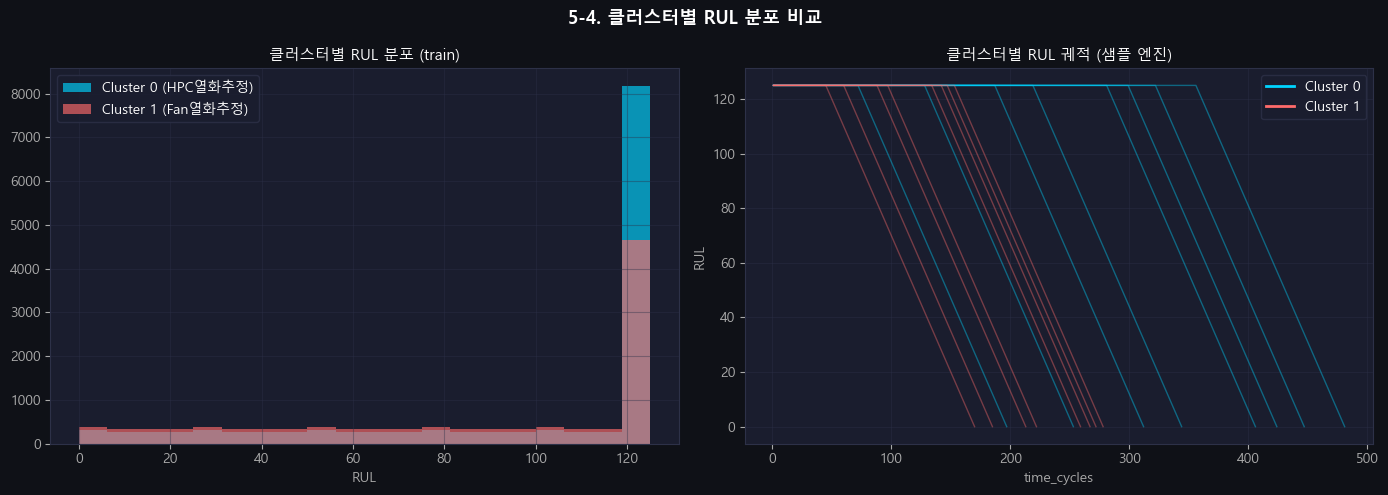

In [62]:
# train_s2에 fault_mode_cluster 컬럼 추가
train_s2 = train_s2.copy()
train_s2['fault_mode_cluster'] = train_s2['unit_nr'].map(cluster_map)

# test에도 동일 클러스터 추정 적용
# (test 엔진은 train과 다른 엔진 — 별도 예측 필요)
# 간단 방법: test의 마지막 N 사이클 slope feature로 클러스터 예측
test_feat  = compute_engine_slope_features(test_s1, USEFUL_SENSORS, slope_window=SLOPE_WINDOW)
test_feat_scaled = scaler_fault.transform(test_feat)
test_cluster_labels = kmeans_fault.predict(test_feat_scaled)
test_cluster_map = dict(zip(test_feat.index, test_cluster_labels.tolist()))

test_s1 = test_s1.copy()
test_s1['fault_mode_cluster'] = test_s1['unit_nr'].map(test_cluster_map)

# fault_mode_cluster를 USEFUL_SENSORS에 포함 여부 결정
FAULT_FEATURE = 'fault_mode_cluster'
print('✅ fault_mode_cluster 컬럼 추가 완료')
print(f'   train 분포:\n{train_s2["fault_mode_cluster"].value_counts().to_string()}')
print(f'   test  분포:\n{test_s1["fault_mode_cluster"].value_counts().to_string()}')
print(f'\n   USE_FAULT_CLUSTER = {USE_FAULT_CLUSTER}')
print(f'   → {"fault_mode_cluster를 ML 피처로 사용" if USE_FAULT_CLUSTER else "실루엣 낮음 — 피처 제외 고려"}')

# 클러스터별 RUL 트렌드 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-4. 클러스터별 RUL 분포 비교', fontsize=13, fontweight='bold')

for ci in range(N_FAULT_MODES):
    sub = train_s2[train_s2['fault_mode_cluster']==ci]['RUL']
    axes[0].hist(sub, bins=20, color=FAULT_COLORS[ci], alpha=0.65,
                 label=f'Cluster {ci} ({CLUSTER_LABEL.get(ci,"")})', edgecolor='none')
axes[0].set_title('클러스터별 RUL 분포 (train)')
axes[0].set_xlabel('RUL'); axes[0].legend()

for ci in range(N_FAULT_MODES):
    units_ci = [u for u, c in cluster_map.items() if c==ci][:8]
    for u in units_ci:
        sub = train_s2[train_s2['unit_nr']==u].sort_values('time_cycles')
        axes[1].plot(sub['time_cycles'], sub['RUL'], color=FAULT_COLORS[ci], alpha=0.4, lw=1)
axes[1].set_title('클러스터별 RUL 궤적 (샘플 엔진)')
axes[1].set_xlabel('time_cycles'); axes[1].set_ylabel('RUL')
for ci in range(N_FAULT_MODES):
    axes[1].plot([], [], color=FAULT_COLORS[ci], label=f'Cluster {ci}', lw=2)
axes[1].legend()
plt.tight_layout(); plt.show()

---
## 6. Gaussian 스무딩 (σ=2)

엔진 단위 적용 — FD001과 동일.  
고장 모드별 노이즈 특성이 다를 경우 σ 조정 검토.

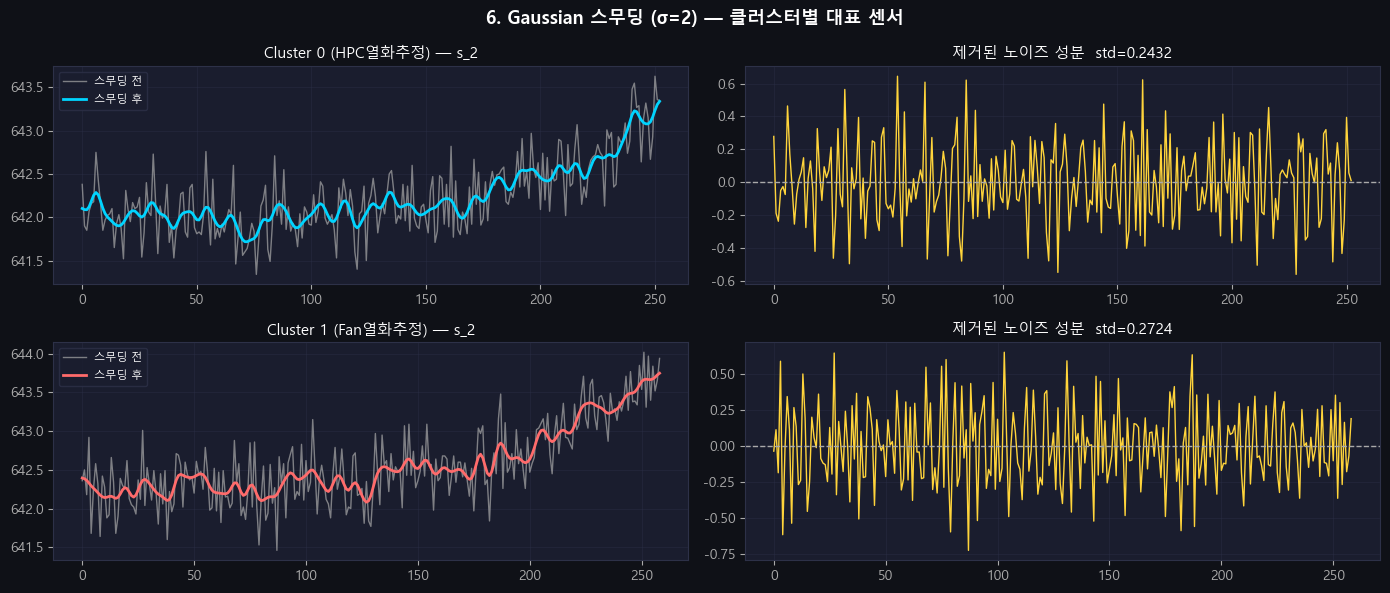

✅ Gaussian 스무딩 완료  |  σ=2


In [63]:
def apply_gaussian(df, sensors, sigma=2):
    df = df.copy()
    for uid in df['unit_nr'].unique():
        mask = df['unit_nr'] == uid
        for s in sensors:
            df.loc[mask, s] = gaussian_filter1d(df.loc[mask, s].values, sigma=sigma)
    return df

train_s3 = apply_gaussian(train_s2, USEFUL_SENSORS, sigma=GAUSS_SIGMA)
test_s3  = apply_gaussian(test_s1,  USEFUL_SENSORS, sigma=GAUSS_SIGMA)

# 클러스터별 스무딩 효과 시각화
fig, axes = plt.subplots(N_FAULT_MODES, 2, figsize=(14, 6))
fig.suptitle(f'6. Gaussian 스무딩 (σ={GAUSS_SIGMA}) — 클러스터별 대표 센서', fontsize=13, fontweight='bold')

sample_sensor = USEFUL_SENSORS[0] if USEFUL_SENSORS else 's_2'
for ci in range(N_FAULT_MODES):
    units_ci = [u for u, c in cluster_map.items() if c==ci]
    if not units_ci: continue
    u = units_ci[0]
    before = train_s2[train_s2['unit_nr']==u][sample_sensor].values
    after  = train_s3[train_s3['unit_nr']==u][sample_sensor].values
    ax = axes[ci][0]
    ax.plot(before, color=GRAY, alpha=0.7, lw=1, label='스무딩 전')
    ax.plot(after,  color=FAULT_COLORS[ci], lw=2, label='스무딩 후')
    ax.set_title(f'Cluster {ci} ({CLUSTER_LABEL.get(ci,"")}) — {sample_sensor}')
    ax.legend(fontsize=8)

    diff = before - after
    ax2 = axes[ci][1]
    ax2.plot(diff, color=C[3], lw=1)
    ax2.axhline(0, color=GRAY, ls='--', lw=1)
    ax2.set_title(f'제거된 노이즈 성분  std={diff.std():.4f}')

plt.tight_layout(); plt.show()
print(f'✅ Gaussian 스무딩 완료  |  σ={GAUSS_SIGMA}')

---
## 7. Validation 분리 (엔진 단위 80:20, random_state=42)

FD001과 동일. 클러스터 비율을 유지하며 분리.

In [64]:
from sklearn.model_selection import train_test_split

all_units = train_s3['unit_nr'].unique()
subtrain_units, valid_units = train_test_split(all_units, test_size=0.2, random_state=42)

subtrain = train_s3[train_s3['unit_nr'].isin(subtrain_units)].reset_index(drop=True)
valid    = train_s3[train_s3['unit_nr'].isin(valid_units)  ].reset_index(drop=True)

print('✅ Validation 분리 완료')
print(f'   Sub-train: {subtrain.shape}  |  엔진 {subtrain["unit_nr"].nunique()}대')
print(f'   Validation: {valid.shape}   |  엔진 {valid["unit_nr"].nunique()}대')

# 클러스터 비율 확인
print('\n클러스터 비율 유지 확인:')
for split_name, split_df in [('Sub-train', subtrain), ('Validation', valid)]:
    n = split_df['unit_nr'].nunique()
    dist = split_df.groupby('unit_nr')['fault_mode_cluster'].first().value_counts(normalize=True)
    print(f'  {split_name}: ' + '  '.join([f'Cluster {k}={v:.1%}' for k, v in dist.items()]))

✅ Validation 분리 완료
   Sub-train: (20012, 22)  |  엔진 80대
   Validation: (4708, 22)   |  엔진 20대

클러스터 비율 유지 확인:
  Sub-train: Cluster 1=56.2%  Cluster 0=43.8%
  Validation: Cluster 1=55.0%  Cluster 0=45.0%


---
## 8. 정규화 — 전체 MinMax (sub-train 기준)

운전 조건이 1가지이므로 FD002처럼 클러스터별 정규화 불필요.  
FD001과 동일하게 **sub-train 전체 기준 MinMax 적용.**

In [65]:
scaler = MinMaxScaler()
scaler.fit(subtrain[USEFUL_SENSORS])

def normalize(df, sensors, sc):
    df = df.copy()
    df[sensors] = sc.transform(df[sensors])
    return df

subtrain_s4 = normalize(subtrain, USEFUL_SENSORS, scaler)
valid_s4    = normalize(valid,    USEFUL_SENSORS, scaler)
test_s4     = normalize(test_s3,  USEFUL_SENSORS, scaler)

# 편의 변수명
train_s4 = normalize(train_s3, USEFUL_SENSORS, scaler)

print('✅ MinMax 정규화 완료 (sub-train 기준)')
print(f'   정규화 범위 확인 — subtrain min: {subtrain_s4[USEFUL_SENSORS].min().min():.4f}'
      f'  max: {subtrain_s4[USEFUL_SENSORS].max().max():.4f}')
print(f'   valid 범위 (클리핑 허용): min={valid_s4[USEFUL_SENSORS].min().min():.4f}'
      f'  max={valid_s4[USEFUL_SENSORS].max().max():.4f}')

✅ MinMax 정규화 완료 (sub-train 기준)
   정규화 범위 확인 — subtrain min: 0.0000  max: 1.0000
   valid 범위 (클리핑 허용): min=-0.0129  max=1.0272


---
## 9. ML 분기 — 시계열 파생변수

FD001과 동일한 파생변수 생성 + **fault_mode_cluster 피처 추가**  
- lag(1,3,5) / diff(1) / rolling mean(3,5) / rolling std(3,5) / EMA(5)

In [66]:
def build_ml_features(df, sensors, lags, diffs, rolls, roll_stds, emas):
    """엔진 단위 시계열 파생변수 생성"""
    df = df.copy().sort_values(['unit_nr','time_cycles'])
    for s in sensors:
        grp = df.groupby('unit_nr')[s]
        for l in lags:
            df[f'{s}_lag{l}'] = grp.shift(l)
        for d in diffs:
            df[f'{s}_diff{d}'] = grp.diff(d)
        for r in rolls:
            df[f'{s}_roll{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        for r in roll_stds:
            df[f'{s}_rollstd{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for e in emas:
            df[f'{s}_ema{e}'] = grp.transform(lambda x: x.ewm(span=e, adjust=False).mean())
    df = df.dropna().reset_index(drop=True)
    return df

subtrain_ml = build_ml_features(subtrain_s4, USEFUL_SENSORS,
                                 TEMPORAL_LAGS, TEMPORAL_DIFFS,
                                 TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)
valid_ml    = build_ml_features(valid_s4,    USEFUL_SENSORS,
                                 TEMPORAL_LAGS, TEMPORAL_DIFFS,
                                 TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)
test_ml     = build_ml_features(test_s4,    USEFUL_SENSORS,
                                 TEMPORAL_LAGS, TEMPORAL_DIFFS,
                                 TEMPORAL_ROLLS, TEMPORAL_ROLL_STDS, TEMPORAL_EMAS)

# ML 피처 목록 구성 (fault_mode_cluster 포함)
base_feats = [c for c in subtrain_ml.columns
              if c not in ['unit_nr','time_cycles','RUL','fault_mode_cluster']
              and c != 'setting_1' and c != 'setting_2' and c != 'setting_3']
if USE_FAULT_CLUSTER:
    ML_FEATURES = base_feats + ['fault_mode_cluster']
    print('✅ fault_mode_cluster → ML 피처에 포함')
else:
    ML_FEATURES = base_feats
    print('⚠️ fault_mode_cluster → 실루엣 낮아 ML 피처에서 제외')

print(f'\n✅ ML 파생변수 생성 완료')
print(f'   ML 피처 수: {len(ML_FEATURES)}개')
print(f'   Sub-train: {subtrain_ml.shape}  |  Validation: {valid_ml.shape}  |  Test: {test_ml.shape}')

✅ fault_mode_cluster → ML 피처에 포함

✅ ML 파생변수 생성 완료
   ML 피처 수: 151개
   Sub-train: (19612, 157)  |  Validation: (4608, 157)  |  Test: (16096, 156)


---
## 10. DL 분기 — 슬라이딩 윈도우 (window=30)

FD001과 동일한 window=30, step=1.  
`fault_mode_cluster`를 DL 피처에 포함.

In [67]:
DL_SENSOR_COLS = USEFUL_SENSORS.copy()
if USE_FAULT_CLUSTER and 'fault_mode_cluster' in subtrain_s4.columns:
    DL_FEATURES = DL_SENSOR_COLS + ['fault_mode_cluster']
else:
    DL_FEATURES = DL_SENSOR_COLS

def make_sliding_windows(df, features, window=30, step=1):
    """슬라이딩 윈도우 → (N, window, F) numpy 배열 + RUL 벡터
    RUL 컬럼 없는 test 데이터도 처리 가능 (has_rul 자동 감지)
    """
    X_list, y_list, sid = [], [], []
    sample_id = 0
    has_rul = 'RUL' in df.columns
    for uid in sorted(df['unit_nr'].unique()):
        sub = df[df['unit_nr']==uid].sort_values('time_cycles')
        arr = sub[features].values
        rul = sub['RUL'].values if has_rul else np.zeros(len(sub))
        for start in range(0, len(arr)-window+1, step):
            X_list.append(arr[start:start+window])
            y_list.append(rul[start+window-1])
            sid.append(sample_id)
            sample_id += 1
    return np.array(X_list), np.array(y_list), np.array(sid)

X_subtrain_dl, y_subtrain_dl, sid_sub = make_sliding_windows(subtrain_s4, DL_FEATURES, WINDOW_SIZE, STEP)
X_valid_dl,    y_valid_dl,    sid_val = make_sliding_windows(valid_s4,    DL_FEATURES, WINDOW_SIZE, STEP)

# test_s4에는 RUL 없음 → 윈도우 생성 후 rul_df로 엔진별 실제 RUL 매핑
X_test_dl, _, sid_te = make_sliding_windows(test_s4, DL_FEATURES, WINDOW_SIZE, STEP)

test_units_sorted = sorted(test_s4['unit_nr'].unique())
y_test_dl = np.zeros(len(sid_te))
cursor = 0
for i, uid in enumerate(test_units_sorted):
    sub  = test_s4[test_s4['unit_nr']==uid]
    n_win = max(0, len(sub) - WINDOW_SIZE + 1)
    if n_win > 0 and i < len(rul_df):
        y_test_dl[cursor + n_win - 1] = rul_df['RUL'].iloc[i]
    cursor += n_win

print(f'✅ DL 슬라이딩 윈도우 완료  |  window={WINDOW_SIZE}  step={STEP}')
print(f'   DL 피처 수: {len(DL_FEATURES)}개')
print(f'   Sub-train X: {X_subtrain_dl.shape}  y: {y_subtrain_dl.shape}')
print(f'   Validation X: {X_valid_dl.shape}    y: {y_valid_dl.shape}')
print(f'   Test X: {X_test_dl.shape}  (RUL=마지막 윈도우에만 실제값 매핑)')

# Long Format CSV 저장용 변환
def to_long_format(X, y, sid, features):
    rows = []
    for xi, yi, si in zip(X, y, sid):
        for t in range(xi.shape[0]):
            row = {'sample_id': int(si), 'timestep': t}
            for j, f in enumerate(features):
                row[f] = xi[t, j]
            row['RUL'] = yi
            rows.append(row)
    return pd.DataFrame(rows)

dl_subtrain_long = to_long_format(X_subtrain_dl, y_subtrain_dl, sid_sub, DL_FEATURES)
dl_valid_long    = to_long_format(X_valid_dl,    y_valid_dl,    sid_val, DL_FEATURES)
dl_test_long     = to_long_format(X_test_dl,     y_test_dl,     sid_te,  DL_FEATURES)

print(f'\n   DL long format — subtrain : {dl_subtrain_long.shape}')
print(f'   DL long format — valid    : {dl_valid_long.shape}')
print(f'   DL long format — test     : {dl_test_long.shape}')

✅ DL 슬라이딩 윈도우 완료  |  window=30  step=1
   DL 피처 수: 16개
   Sub-train X: (17692, 30, 16)  y: (17692,)
   Validation X: (4128, 30, 16)    y: (4128,)
   Test X: (13696, 30, 16)  (RUL=마지막 윈도우에만 실제값 매핑)

   DL long format — subtrain : (530760, 19)
   DL long format — valid    : (123840, 19)
   DL long format — test     : (410880, 19)


---
## 11. val_eval 생성 (수명 50~90% 절단)

FD001과 동일 방식. 테스트셋과 유사한 RUL 분포 확보.

In [68]:
def make_val_eval(df_ml, df_dl, features_ml, features_dl, window,
                  cut_low=0.5, cut_high=0.9, random_state=42):
    """수명 50~90% 사이에서 절단 — test와 유사한 RUL 분포

    Parameters
    ----------
    df_ml       : valid_ml  — ML 파생변수 포함 (lag/diff/roll/ema)
    df_dl       : valid_s4  — DL 슬라이딩 윈도우용 정규화 원본
    features_ml : ML_FEATURES
    features_dl : DL_FEATURES
    """
    rng = np.random.RandomState(random_state)
    ml_rows, dl_rows = [], []

    common_units = sorted(set(df_ml['unit_nr'].unique()) & set(df_dl['unit_nr'].unique()))

    for uid in common_units:
        sub_ml = df_ml[df_ml['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)
        sub_dl = df_dl[df_dl['unit_nr']==uid].sort_values('time_cycles').reset_index(drop=True)

        n_ml, n_dl = len(sub_ml), len(sub_dl)
        if n_ml < 2 or n_dl < window:
            continue

        # cut point 결정 (ML 행 기준)
        cut_i = rng.randint(max(1, int(n_ml * cut_low)), int(n_ml * cut_high) + 1)
        cut_i = max(1, min(cut_i, n_ml))

        # ML: cut point 행의 피처 추출
        ml_cols = [c for c in ['unit_nr', 'time_cycles'] + features_ml + ['RUL']
                   if c in sub_ml.columns]
        row_ml = sub_ml.iloc[cut_i - 1][ml_cols].to_dict()
        ml_rows.append(row_ml)

        # DL: cut point 비율에 대응하는 dl 인덱스
        cut_ratio = (cut_i - 1) / max(n_ml - 1, 1)
        cut_dl    = max(window, min(int(cut_ratio * n_dl) + 1, n_dl))
        seg       = sub_dl.iloc[cut_dl - window : cut_dl]

        if len(seg) == window:
            rul_at_cut = sub_ml.iloc[cut_i - 1]['RUL']
            for t_i, (_, r) in enumerate(seg.iterrows()):
                dr = {'sample_id': uid, 'timestep': t_i}
                for f in features_dl:
                    dr[f] = r[f] if f in r.index else np.nan
                dr['RUL'] = rul_at_cut
                dl_rows.append(dr)

    return pd.DataFrame(ml_rows), pd.DataFrame(dl_rows)

# valid_ml  → ML 파생변수 포함 (lag/roll/ema 존재)
# valid_s4  → DL 슬라이딩 윈도우용 정규화 원본 (USEFUL_SENSORS + fault_mode_cluster)
val_eval_ml, dl_val_eval_long = make_val_eval(
    valid_ml, valid_s4, ML_FEATURES, DL_FEATURES, WINDOW_SIZE)

old_rul = valid_s4.groupby('unit_nr')['RUL'].last().values
y_ve    = val_eval_ml['RUL'].values if 'RUL' in val_eval_ml.columns else np.array([])

print(f'✅ val_eval 생성 완료')
print(f'   ML val_eval shape : {val_eval_ml.shape}')
print(f'   DL val_eval shape : {dl_val_eval_long.shape}')
if len(y_ve):
    print(f'   RUL 분포: μ={y_ve.mean():.1f}  min={y_ve.min():.0f}  max={y_ve.max():.0f}')

✅ val_eval 생성 완료
   ML val_eval shape : (20, 154)
   DL val_eval shape : (600, 19)
   RUL 분포: μ=65.8  min=16  max=114


---
## 12. 전처리 후 검증

### 12-1. 센서 상관관계 전처리 전후 비교

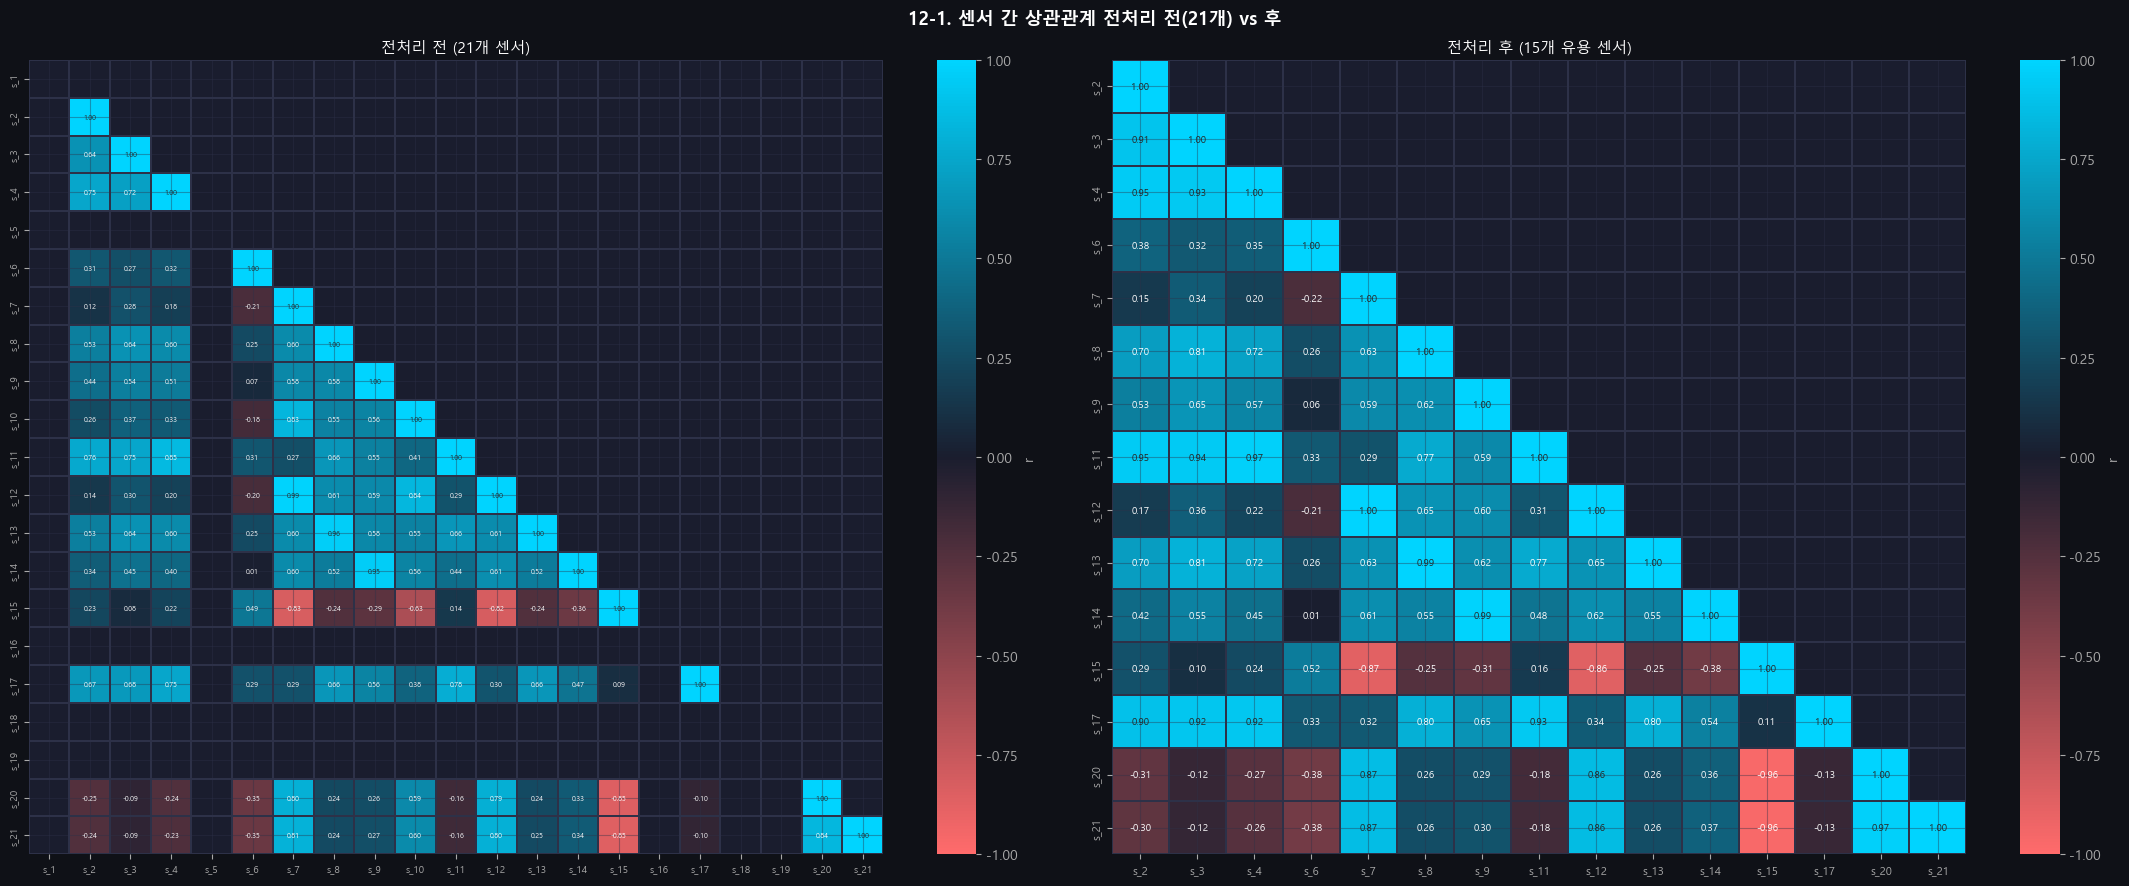

In [69]:
corr_after = train_s4[USEFUL_SENSORS].corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('12-1. 센서 간 상관관계 전처리 전(21개) vs 후', fontsize=13, fontweight='bold')

cmap_rg2 = LinearSegmentedColormap.from_list('rg',['#ff6b6b','#1a1d2e','#00d4ff'],N=256)
mask_b = np.triu(np.ones_like(corr_before, dtype=bool), k=1)
sns.heatmap(corr_before, ax=axes[0], mask=mask_b, cmap=cmap_rg2, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size':5},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label':'r'})
axes[0].set_title(f'전처리 전 (21개 센서)', fontsize=11); axes[0].tick_params(labelsize=7)

mask_a = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(corr_after, ax=axes[1], mask=mask_a, cmap=cmap_rg2, center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.3, linecolor=GRID, cbar_kws={'label':'r'})
axes[1].set_title(f'전처리 후 ({len(USEFUL_SENSORS)}개 유용 센서)', fontsize=11)
axes[1].tick_params(labelsize=8)
plt.tight_layout(); plt.show()

### 12-2. Train vs Test 분포 비교 (KS 검정)

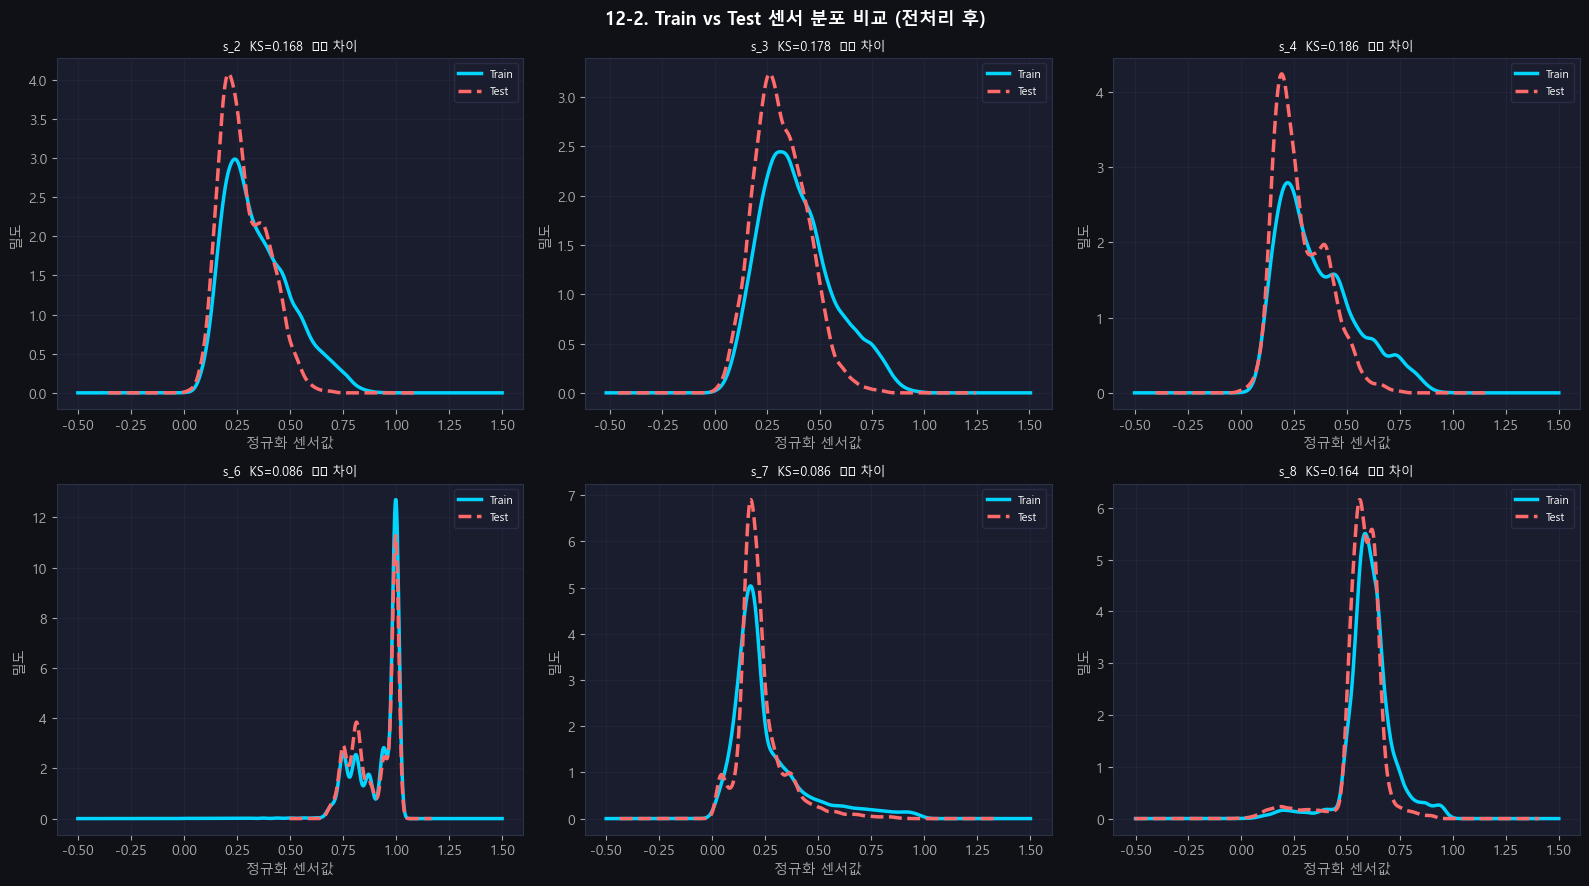

,KS통계량,p-value,판정
센서,,,
s_2,0.1675,0.0,⚠️ 차이
s_3,0.1782,0.0,⚠️ 차이
s_4,0.1858,0.0,⚠️ 차이
s_6,0.0858,0.0,⚠️ 차이
s_7,0.0859,0.0,⚠️ 차이
s_8,0.1642,0.0,⚠️ 차이


In [70]:
show6 = USEFUL_SENSORS[:6]; ks_rows = []
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('12-2. Train vs Test 센서 분포 비교 (전처리 후)', fontsize=13, fontweight='bold')
for ax, s in zip(axes.flat, show6):
    tr_v = train_s4[s].dropna(); te_v = test_s4[s].dropna()
    try: tr_v.plot.kde(ax=ax, color=C[0], lw=2.5, label='Train')
    except: pass
    try: te_v.plot.kde(ax=ax, color=C[1], lw=2.5, ls='--', label='Test')
    except: pass
    ks_stat, ks_p = ks_2samp(tr_v, te_v)
    verdict = '✅ 유사' if ks_p>0.05 else '⚠️ 차이'
    ks_rows.append({'센서':s,'KS통계량':round(ks_stat,4),'p-value':round(ks_p,4),'판정':verdict})
    ax.set_title(f'{s}  KS={ks_stat:.3f}  {verdict}', fontsize=9)
    ax.set_xlabel('정규화 센서값'); ax.set_ylabel('밀도'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(pd.DataFrame(ks_rows).set_index('센서'))

### 12-3. 클러스터별 RUL 상관계수 비교 (전처리 후)

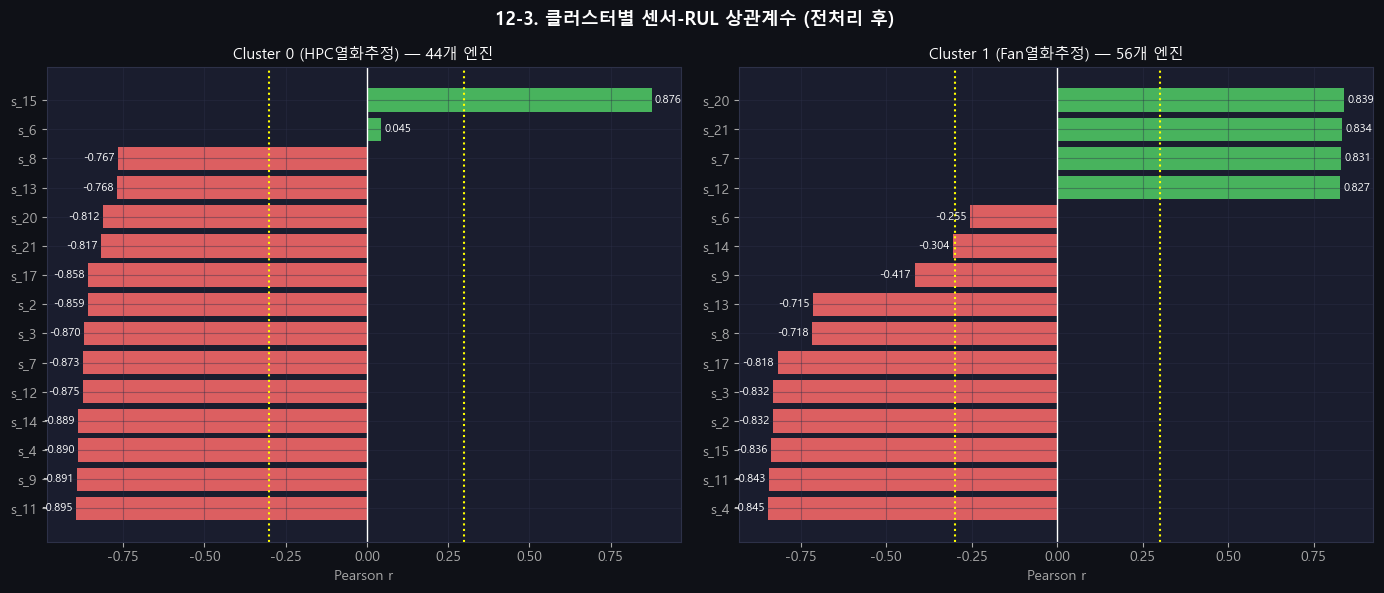

📌 클러스터별로 고상관 센서 집합이 다르면 고장 모드 분리가 유효함


In [71]:
fig, axes = plt.subplots(1, N_FAULT_MODES, figsize=(14, 6))
fig.suptitle('12-3. 클러스터별 센서-RUL 상관계수 (전처리 후)', fontsize=13, fontweight='bold')

for ci, ax in enumerate(axes):
    sub_c = train_s4[train_s4['fault_mode_cluster']==ci]
    if len(sub_c) == 0: continue
    corr_c = sub_c[USEFUL_SENSORS+['RUL']].corr()['RUL'][USEFUL_SENSORS].sort_values()
    bc = [C[1] if v<0 else C[2] for v in corr_c.values]
    bars = ax.barh(corr_c.index, corr_c.values, color=bc, alpha=0.85)
    ax.axvline(0, color='white', lw=1)
    ax.axvline(0.3, color='yellow', lw=1.5, ls=':')
    ax.axvline(-0.3, color='yellow', lw=1.5, ls=':')
    for bar, val in zip(bars, corr_c.values):
        ax.text(val+(0.01 if val>=0 else -0.01), bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontsize=8)
    n_eng = sub_c['unit_nr'].nunique()
    ax.set_title(f'Cluster {ci} ({CLUSTER_LABEL.get(ci,"")}) — {n_eng}개 엔진')
    ax.set_xlabel('Pearson r')
plt.tight_layout(); plt.show()
print('📌 클러스터별로 고상관 센서 집합이 다르면 고장 모드 분리가 유효함')

### 12-4. ML 파생변수 다중공선성 (|r| > 0.95)

In [72]:
print(f'=== 12-4. ML 파생변수 다중공선성 (|r|>0.95) — {len(ML_FEATURES)}개 피처 ===')
corr_ml  = subtrain_ml[ML_FEATURES].corr().abs()
upper_ml = corr_ml.where(np.triu(np.ones(corr_ml.shape), k=1).astype(bool))
HIGH_THR = 0.95
high_pairs_ml = (upper_ml.stack().reset_index()
                 .rename(columns={'level_0':'피처A','level_1':'피처B',0:'|r|'})
                 .query('`|r|` >= @HIGH_THR')
                 .sort_values('|r|', ascending=False).reset_index(drop=True))
print(f'|r|≥{HIGH_THR} 쌍: {len(high_pairs_ml)}개 / 전체 {len(ML_FEATURES)*(len(ML_FEATURES)-1)//2}쌍')
if len(high_pairs_ml): display(high_pairs_ml.head(20))
print('→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장')

=== 12-4. ML 파생변수 다중공선성 (|r|>0.95) — 151개 피처 ===
|r|≥0.95 쌍: 721개 / 전체 11325쌍


,피처A,피처B,|r|
0,s_12_lag1,s_12_roll3,0.999996
1,s_7_lag1,s_7_roll3,0.999994
2,s_6_lag1,s_6_roll3,0.999992
3,s_14_lag1,s_14_roll3,0.999986
4,s_9_lag1,s_9_roll3,0.999984
5,s_12_roll5,s_12_ema5,0.999971
6,s_15_lag1,s_15_roll3,0.999960
7,s_7_roll5,s_7_ema5,0.999959
8,s_11_lag1,s_11_roll3,0.999955
9,s_6_roll5,s_6_ema5,0.999946


→ 실제 제거는 모델 피처 중요도 확인 후 결정 권장


---
## 13. CSV 저장 & 최종 요약

In [73]:
import joblib

OUTPUT_DIR = 'preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 파일 경로 ────────────────────────────────────────────────────────────
ml_subtrain_path  = os.path.join(OUTPUT_DIR, 'FD003_ml_subtrain.csv')
ml_valid_path     = os.path.join(OUTPUT_DIR, 'FD003_ml_valid.csv')
ml_test_path      = os.path.join(OUTPUT_DIR, 'FD003_ml_test.csv')
ml_test_eval_path = os.path.join(OUTPUT_DIR, 'FD003_ml_test_eval.csv')
ml_val_eval_path  = os.path.join(OUTPUT_DIR, 'FD003_ml_val_eval.csv')

dl_dir = os.path.join(OUTPUT_DIR, 'dl')
os.makedirs(dl_dir, exist_ok=True)
dl_subtrain_path  = os.path.join(dl_dir, 'FD003_dl_subtrain_long.csv')
dl_valid_path     = os.path.join(dl_dir, 'FD003_dl_valid_long.csv')
dl_test_path      = os.path.join(dl_dir, 'FD003_dl_test_long.csv')
dl_val_eval_path  = os.path.join(dl_dir, 'FD003_dl_val_eval_long.csv')

rul_path          = os.path.join(OUTPUT_DIR, 'FD003_test_RUL.csv')
scaler_path       = os.path.join(OUTPUT_DIR, 'FD003_scaler.pkl')
fault_scaler_path = os.path.join(OUTPUT_DIR, 'FD003_fault_scaler.pkl')
fault_km_path     = os.path.join(OUTPUT_DIR, 'FD003_fault_kmeans.pkl')
ml_feat_path      = os.path.join(OUTPUT_DIR, 'FD003_ml_features.txt')
dl_feat_path      = os.path.join(OUTPUT_DIR, 'FD003_dl_features.txt')

# ── ML CSV 저장 ──────────────────────────────────────────────────────────
subtrain_ml.to_csv(ml_subtrain_path, index=False, encoding='utf-8-sig')
valid_ml.to_csv(ml_valid_path,       index=False, encoding='utf-8-sig')
test_ml.to_csv(ml_test_path,         index=False, encoding='utf-8-sig')
rul_df.to_csv(rul_path,              index=False, encoding='utf-8-sig')

# test_last_ml: 엔진별 마지막 행 + 실제 RUL (unit_nr 오름차순 정렬로 rul_df 순서 일치)
test_last_ml = (test_ml
                .sort_values(['unit_nr', 'time_cycles'])
                .groupby('unit_nr', as_index=False).last()
                .sort_values('unit_nr')
                .reset_index(drop=True))
test_last_ml['RUL'] = rul_df['RUL'].values
test_last_ml.to_csv(ml_test_eval_path, index=False, encoding='utf-8-sig')

# val_eval 저장
val_eval_ml_cols = [c for c in val_eval_ml.columns if c in ['unit_nr','time_cycles'] + ML_FEATURES + ['RUL']]
val_eval_ml[val_eval_ml_cols].to_csv(ml_val_eval_path, index=False, encoding='utf-8-sig')

# ── DL CSV 저장 ──────────────────────────────────────────────────────────
dl_subtrain_long.to_csv(dl_subtrain_path, index=False, encoding='utf-8-sig')
dl_valid_long.to_csv(dl_valid_path,       index=False, encoding='utf-8-sig')
dl_test_long.to_csv(dl_test_path,         index=False, encoding='utf-8-sig')
dl_val_eval_long.to_csv(dl_val_eval_path, index=False, encoding='utf-8-sig')

# ── 모델/스케일러/피처 저장 ──────────────────────────────────────────────
joblib.dump(scaler,        scaler_path)
joblib.dump(scaler_fault,  fault_scaler_path)
joblib.dump(kmeans_fault,  fault_km_path)

with open(ml_feat_path, 'w', encoding='utf-8') as f:
    for col in ['unit_nr', 'time_cycles'] + ML_FEATURES + ['RUL']:
        f.write(f'{col}\n')
with open(dl_feat_path, 'w', encoding='utf-8') as f:
    for col in DL_FEATURES:
        f.write(f'{col}\n')

# ── 최종 요약 ────────────────────────────────────────────────────────────
n_val_eval_samples = dl_val_eval_long['sample_id'].nunique() if 'sample_id' in dl_val_eval_long.columns and len(dl_val_eval_long) > 0 else 0

print('=' * 74)
print('  FD003 ML / DL 통합 전처리 파이프라인 완료')
print('=' * 74)
print()
print('■ 공통 파이프라인')
print('  상수 센서 제거(Fan 재검토) → 고장모드 클러스터링(k=2) → RUL Cap=125')
print('  → Gaussian(σ=2) → Validation 분리(80:20) → Global MinMax 정규화')

print()
print('■ FD003 신규 — 고장 모드 클러스터링')
print(f'  Silhouette Score(k=2): {sil_scores[2]:.4f}')
print(f'  fault_mode_cluster 피처 사용: {USE_FAULT_CLUSTER}')
for ci in range(N_FAULT_MODES):
    n = sum(1 for v in cluster_map.values() if v == ci)
    print(f'  Cluster {ci} ({CLUSTER_LABEL.get(ci, "")}): {n}개 엔진')

print()
print('■ ML 분기')
ml_summary = pd.DataFrame({
    '구분'      : ['Sub-train', 'Validation', 'Test(전체)', 'Test(평가용)', 'val_eval'],
    'shape'     : [str(subtrain_ml.shape), str(valid_ml.shape), str(test_ml.shape),
                   str(test_last_ml.shape), str(val_eval_ml.shape)],
    'ML피처 수' : [len(ML_FEATURES)] * 5,
    '파일'      : ['FD003_ml_subtrain.csv', 'FD003_ml_valid.csv', 'FD003_ml_test.csv',
                   'FD003_ml_test_eval.csv', 'FD003_ml_val_eval.csv'],
}).set_index('구분')
display(ml_summary)

print()
print('■ DL 분기 — 슬라이딩 윈도우 Long Format')
dl_summary = pd.DataFrame({
    '구분'       : ['Sub-train', 'Validation', 'Test', 'val_eval'],
    'shape'      : [str(dl_subtrain_long.shape), str(dl_valid_long.shape),
                    str(dl_test_long.shape),      str(dl_val_eval_long.shape)],
    '샘플 수'    : [X_subtrain_dl.shape[0], X_valid_dl.shape[0],
                    X_test_dl.shape[0],      n_val_eval_samples],
    'window_size': [WINDOW_SIZE] * 4,
    'DL피처 수'  : [len(DL_FEATURES)] * 4,
    '파일(dl/)'  : ['FD003_dl_subtrain_long.csv', 'FD003_dl_valid_long.csv',
                    'FD003_dl_test_long.csv',     'FD003_dl_val_eval_long.csv'],
}).set_index('구분')
display(dl_summary)

print()
print(f'📄 저장 경로: {os.path.abspath(OUTPUT_DIR)}/')
print()
print('── ML 활용법 ──')
print('  subtrain = pd.read_csv("FD003_ml_subtrain.csv")')
print('  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])')
print()
print('── DL 활용법 (Long Format → 3D 복원) ──')
print('  df  = pd.read_csv("dl/FD003_dl_subtrain_long.csv")')
print('  grp = df.groupby("sample_id")')
print('  X   = np.stack([grp.get_group(i)[DL_FEATURES].values')
print('                  for i in range(df["sample_id"].nunique())])  # (N, 30, F)')
print('  y   = df.groupby("sample_id")["RUL"].last().values')
print()
print('── 고장 모드 클러스터 추론 (신규 엔진) ──')
print('  feat = compute_engine_slope_features(new_df, USEFUL_SENSORS)')
print('  feat_sc = scaler_fault.transform(feat)')
print('  cluster = kmeans_fault.predict(feat_sc)  # 0=HPC추정, 1=Fan추정')

  FD003 ML / DL 통합 전처리 파이프라인 완료

■ 공통 파이프라인
  상수 센서 제거(Fan 재검토) → 고장모드 클러스터링(k=2) → RUL Cap=125
  → Gaussian(σ=2) → Validation 분리(80:20) → Global MinMax 정규화

■ FD003 신규 — 고장 모드 클러스터링
  Silhouette Score(k=2): 0.4691
  fault_mode_cluster 피처 사용: True
  Cluster 0 (HPC열화추정): 44개 엔진
  Cluster 1 (Fan열화추정): 56개 엔진

■ ML 분기


,shape,ML피처 수,파일
구분,,,
Sub-train,"(19612, 157)",151,FD003_ml_subtrain.csv
Validation,"(4608, 157)",151,FD003_ml_valid.csv
Test(전체),"(16096, 156)",151,FD003_ml_test.csv
Test(평가용),"(100, 157)",151,FD003_ml_test_eval.csv
val_eval,"(20, 154)",151,FD003_ml_val_eval.csv



■ DL 분기 — 슬라이딩 윈도우 Long Format


,shape,샘플 수,window_size,DL피처 수,파일(dl/)
구분,,,,,
Sub-train,"(530760, 19)",17692,30,16,FD003_dl_subtrain_long.csv
Validation,"(123840, 19)",4128,30,16,FD003_dl_valid_long.csv
Test,"(410880, 19)",13696,30,16,FD003_dl_test_long.csv
val_eval,"(600, 19)",20,30,16,FD003_dl_val_eval_long.csv



📄 저장 경로: c:\Users\matth\OneDrive\바탕 화면\부캠\프로젝트\최종 프로젝트\cmapss\preprocessed/

── ML 활용법 ──
  subtrain = pd.read_csv("FD003_ml_subtrain.csv")
  X_train  = subtrain[ML_FEATURES]  →  model.fit(X_train, subtrain["RUL"])

── DL 활용법 (Long Format → 3D 복원) ──
  df  = pd.read_csv("dl/FD003_dl_subtrain_long.csv")
  grp = df.groupby("sample_id")
  X   = np.stack([grp.get_group(i)[DL_FEATURES].values
                  for i in range(df["sample_id"].nunique())])  # (N, 30, F)
  y   = df.groupby("sample_id")["RUL"].last().values

── 고장 모드 클러스터 추론 (신규 엔진) ──
  feat = compute_engine_slope_features(new_df, USEFUL_SENSORS)
  feat_sc = scaler_fault.transform(feat)
  cluster = kmeans_fault.predict(feat_sc)  # 0=HPC추정, 1=Fan추정
